In [36]:
import matplotlib
import matplotlib.pyplot as plt
#from collections import OrderedDict
import seaborn as sns

import numpy as np
import os
import scipy
import pickle

from neurolib.models.aln import ALNModel
import neurolib.utils.functions as func
from neurolib.utils import costFunctions as cost
from neurolib.utils import plotFunctions as plotFunc
from neurolib.models import jacobian_aln as jac_aln
from neurolib.utils import func_optimize as fo

# a nice color map
#sns.set()
#cmap = plt.get_cmap('plasma')
plt.rcParams['image.cmap'] = 'plasma'
cpalette = sns.color_palette('plasma')
np.set_printoptions(precision=4)

#matplotlib.style.use('classic')

font = {
    'family' : 'sans',
    'weight' : 'normal',
    'size'   : 14
       }

matplotlib.rc('font', **font)
matplotlib.rc('xtick', labelsize=16) 
matplotlib.rc('ytick', labelsize=16) 
matplotlib.rc('grid', c='0.5', ls='-', lw=0.5)  # solid gray grid lines
matplotlib.rc('savefig', dpi=300)       # higher res outputs
#print (matplotlib.rcParams)
    
# This will reload all imports as soon as the code changes
%load_ext autoreload
%autoreload 2 

path = os.getcwd()

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Bistability

In [22]:
def step_control(maxI_ = 1.):
    control_ = aln.getZeroControl()
    for i_time in range(control_.shape[2]):
        if ( float(i_time/control_.shape[2]) < 0.1):
            control_[:,:,i_time] = - maxI_
        elif ( float(i_time/control_.shape[2]) > 0.5 and float(i_time/control_.shape[2]) < 0.6 ):
            control_[:,:,i_time] = maxI_
    return control_

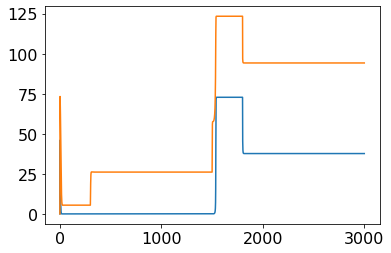

[[2.3474e-04 2.6062e+01]
 [3.7674e+01 9.4217e+01]]


In [23]:
aln = ALNModel()

aln.params['duration'] = 3000.

control0 = aln.getZeroControl()
target = aln.getZeroTarget()
control0 = step_control(maxI_ = 1.)

aln.params.ext_exc_current = 2.3
aln.params.ext_inh_current = 2.5

# no delay
aln.params.signalV = 0.
aln.params.de = 0.
aln.params.di = 0.

# NO ADAPTATION
aln.params.IA_init = np.array([0.])
aln.params.a = 0.
aln.params.b = 0.

aln.params.mue_ext_mean = 0.0
aln.params.mui_ext_mean = 0.0

state = aln.getZeroState()
aln.run(control = control0)

plt.plot(aln.t, aln.rates_exc[0,:])
plt.plot(aln.t, aln.rates_inh[0,:])
plt.show()

output = aln.output_vars

for i in range(len(output)):
    state[:,i,:] = aln[output[i]][:,:]
    
steady_rates = np.zeros((2, 2))
steady_rates[0,0] = np.mean(state[0,0,3000:15000]) # low state exc
steady_rates[0,1] = np.mean(state[0,1,3000:15000]) # low state inh
steady_rates[1,0] = np.mean(state[0,0,19500:]) # high state exc
steady_rates[1,1] = np.mean(state[0,1,19500:]) #high state inh

print(steady_rates)

state_vars = aln.state_vars
init_vars = aln.init_vars

high_state_vars = np.zeros(( len(state_vars) ))
for i in range(len(state_vars)):
    #print("final value of state var ", aln.state_vars[i], " : ", aln.state[state_vars[i]])
    if aln.state[state_vars[i]].size == 1:
        high_state_vars[i] = aln.state[state_vars[i]][0] * 1.01
    else:
        high_state_vars[i] = aln.state[state_vars[i]][0,-1] * 1.01

low state vars =  [ 8.3127e-005  2.5847e+001 -3.3072e-001  1.0327e+000  0.0000e+000
  1.6420e-005  7.9023e-001  1.5346e-005  8.7951e-001  1.0135e-006
  2.5945e-003  8.8534e-007  1.9317e-003  2.3986e-264  1.7990e-264
  1.5030e+000  1.4869e+000 -7.0969e+001  2.1153e+001  2.3058e+000]


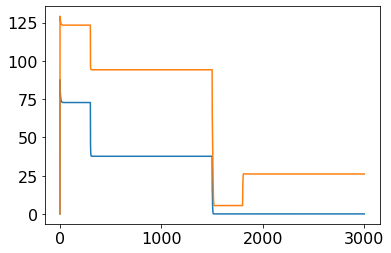

In [24]:
control0 = step_control(maxI_ = -1.)
aln.run(control = control0)
plt.plot(aln.t, aln.rates_exc[0,:])
plt.plot(aln.t, aln.rates_inh[0,:])

low_state_vars = np.zeros(( len(state_vars) ))
for i in range(len(state_vars)):
    #print("final value of state var ", aln.state_vars[i], " : ", aln.state[state_vars[i]])
    if aln.state[state_vars[i]].size == 1:
        low_state_vars[i] = aln.state[state_vars[i]][0] * 0.99
    else:
        low_state_vars[i] = aln.state[state_vars[i]][0,-1] * 0.99

print("low state vars = ", low_state_vars)

### State switching task in bistability regime: Switch from up to down state

In [114]:
dur = 20.
dur_pre = 5.
dur_post = 5.
aln.params.duration = dur

control0 = aln.getZeroControl()

# set high state rates as target
target_lh = aln.getZeroTarget()
target_lh[:,0,:] = steady_rates[1,0]
target_lh[:,1,:] = steady_rates[1,1] 

max_it = 5
tol = 1e-12
incl_step = int(1. + aln.params.duration/aln.params.dt)
start_step = 100.
test_step = 1e-6

c_scheme = np.zeros(( 1,1 ))
c_scheme[0,0] = 1.
u_mat = np.identity(1)
u_scheme = np.array([[1.]])

alg = "A1"
#alg = "A2"

plot_only = False

init_1nA_lh = control0.copy()
init_1nA_lh[:,0,:50] = 4.
#init_1nA_lh[:,1,:50] = 2.

total cost with zero control =  60885.99150259075
total cost with step control =  12551.468004324293


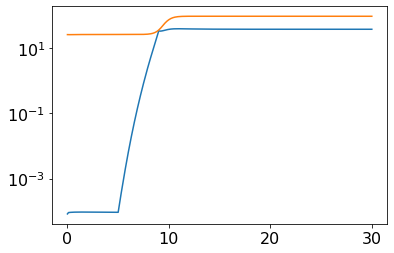

total cost with computed control =  60884.57945129784


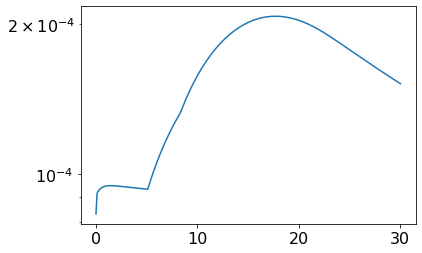

In [97]:
aln.params.duration = dur+dur_pre+dur_post
control0 = aln.getZeroControl()
setinitvars(low_state_vars)
aln.run(control = control0)
state0 = fo.updateFullState(aln, control0)
cost0 = cost.f_int(aln.params['dt'], cost.f_cost(state0[:,:,50:251], target_lh, control0[:,:,50:251]) )
print("total cost with zero control = ", cost0)

testC = aln.getZeroControl()
testC[:,0,50:90] = 4.7

setinitvars(low_state_vars)
aln.run(control = testC)
state1 = fo.updateFullState(aln, testC)
cost1 = cost.f_cost(state1[:,:,50:251], target_lh, testC[:,:,50:251])
cost1int = cost.f_int(aln.params['dt'], cost1 )
print("total cost with step control = ", cost1int)

plt.plot(aln.t, aln.rates_exc[0,:])
plt.plot(aln.t, aln.rates_inh[0,:])
plt.yscale('log')
plt.show()

testC2 = aln.getZeroControl()
testC2[:,0,:] = 100. * bestControlH[:,0,:]

setinitvars(low_state_vars)
aln.run(control = testC2)
state2 = fo.updateFullState(aln, testC2)
cost2 = cost.f_cost(state2[:,:,50:251], target_lh, testC2[:,:,50:251])
cost2int = cost.f_int(aln.params['dt'], cost2 )
print("total cost with computed control = ", cost2int)

plt.plot(aln.t, aln.rates_exc[0,:])
#plt.plot(aln.t, aln.rates_inh[0,:])
plt.yscale('log')

In [72]:
# D: precision & energy equally penalize, max 1nA control
cost.setParams(1.0, 0.0, 0.)
max_cntrl = 1000. * 5.

def setinitvars(vars):
    for iv in range(len(init_vars)):
        for sv in range(len(state_vars)):
            if state_vars[sv] in init_vars[iv]:
                if aln.params[init_vars[iv]].ndim == 2:
                    aln.params[init_vars[iv]][0,0] = vars[sv]
                else:
                    aln.params[init_vars[iv]][0] = vars[sv]
                
opt_params = {"max_it": max_it,
              "tol": tol,
              "incl_step": incl_step,
              "start_step": start_step,
              "test_step": test_step,
              "dur": dur,
              "dur_pre": dur_pre,
              "dur_post": dur_post,
}

set cost params


RUN  0 , total integrated cost =  60885.99150259075
dir =  [[[-0.00000000e+00  1.23778837e+00  1.23259124e+00  1.22737067e+00
    1.22212651e+00  1.21685859e+00  1.21156676e+00  1.20625085e+00
    1.20091073e+00  1.19554625e+00]
  [-0.00000000e+00  2.08476519e+03  2.08477025e+03  2.08477513e+03
    2.08477986e+03  2.08478443e+03  2.08478885e+03  2.08479312e+03
    2.08479724e+03  2.08480123e+03]]]
step =  10.0  , cost =  125805.1726027873 , initial cost =  60885.99150259075
step =  5.0  , cost =  66452.70218396955 , initial cost =  60885.99150259075
step =  4.545454545454545  , cost =  56646.23249367894 , initial cost =  60885.99150259075
step =  4.413062665489849  , cost =  53941.7630014764 , initial cost =  60885.99150259075
step =  4.284526859698882  , cost =  51394.81463443531 , initial cost =  60885.99150259075
step =  4.159734815241634  , cost =  48990.3995999621 , initial cost =  60885.99150259075
step =  4.038577490525857  , cost =  46738.60723910809 , initial cost =  60885.991

step =  0.0006103515625  , cost =  20471.534633373834 , initial cost =  14304.20074453848
step =  0.00030517578125  , cost =  16114.779703037228 , initial cost =  14304.20074453848
step =  0.0002543131510416667  , cost =  15526.171460949196 , initial cost =  14304.20074453848
step =  0.0002311937736742424  , cost =  15277.116247990509 , initial cost =  14304.20074453848
step =  0.0002101761578856749  , cost =  15061.598442468408 , initial cost =  14304.20074453848
step =  0.00019106923444152263  , cost =  14876.785097314985 , initial cost =  14304.20074453848
step =  0.00017369930403774784  , cost =  14718.216551471702 , initial cost =  14304.20074453848
step =  0.0001579084582161344  , cost =  14583.896802903717 , initial cost =  14304.20074453848
step =  0.00014355314383284943  , cost =  14470.931255802006 , initial cost =  14304.20074453848
step =  0.0001305028580298631  , cost =  14376.414954935419 , initial cost =  14304.20074453848
step =  0.00012670180391248845  , cost =  14350.

step =  0.0005595373320260893  , cost =  14165.151881253376 , initial cost =  14304.20074453848
step =  0.0005432401281806692  , cost =  14099.308239639742 , initial cost =  14304.20074453848
step =  0.000527417600175407  , cost =  14038.248640235703 , initial cost =  14304.20074453848
step =  0.0005120559225003951  , cost =  13981.574213931306 , initial cost =  14304.20074453848
step =  0.0004971416723304807  , cost =  13929.12095726021 , initial cost =  14304.20074453848
step =  0.00048266181779658317  , cost =  13881.517188463118 , initial cost =  14304.20074453848
step =  0.00046860370659862445  , cost =  13838.401386459642 , initial cost =  14304.20074453848
step =  0.0004549550549501208  , cost =  13798.984345937239 , initial cost =  14304.20074453848
step =  0.0004417039368447774  , cost =  13762.06809982398 , initial cost =  14304.20074453848
step =  0.00042883877363570624  , cost =  13728.532954321667 , initial cost =  14304.20074453848
step =  0.00041634832391816137  , cost =

step =  0.0018711346004483072  , cost =  12001.243480421626 , initial cost =  13509.509884169547
step =  0.0018166355344158322  , cost =  11921.495993725619 , initial cost =  13509.509884169547
step =  0.0017637238198211962  , cost =  11851.42954516047 , initial cost =  13509.509884169547
step =  0.0017123532231273749  , cost =  11789.11484944854 , initial cost =  13509.509884169547
step =  0.0016624788574052182  , cost =  11735.808558996645 , initial cost =  13509.509884169547
step =  0.0016140571431118623  , cost =  11689.835628815461 , initial cost =  13509.509884169547
step =  0.0015670457700115168  , cost =  11650.317862758264 , initial cost =  13509.509884169547
step =  0.001521403660205356  , cost =  11617.66468633098 , initial cost =  13509.509884169547
step =  0.0014770909322382097  , cost =  11590.81916295075 , initial cost =  13509.509884169547
step =  0.001434068866250689  , cost =  11569.17086782437 , initial cost =  13509.509884169547
step =  0.0013922998701463  , cost = 

step =  0.0023012595437835797  , cost =  11533.71643360432 , initial cost =  12804.5426051794
step =  0.0022342325667801745  , cost =  11408.689497650286 , initial cost =  12804.5426051794
step =  0.002169157831825412  , cost =  11295.382932331764 , initial cost =  12804.5426051794
step =  0.0021059784775004  , cost =  11196.838250204255 , initial cost =  12804.5426051794
step =  0.0020446392985440775  , cost =  11108.632533951737 , initial cost =  12804.5426051794
step =  0.001985086697615609  , cost =  11031.002758903727 , initial cost =  12804.5426051794
step =  0.0019272686384617563  , cost =  10963.465397350332 , initial cost =  12804.5426051794
step =  0.0018711346004483072  , cost =  10905.439766245147 , initial cost =  12804.5426051794
step =  0.0018166355344158322  , cost =  10855.861812051182 , initial cost =  12804.5426051794
step =  0.0017637238198211962  , cost =  10813.901641582346 , initial cost =  12804.5426051794
step =  0.0017123532231273749  , cost =  10778.962436135

ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


step =  0.0017353262654603296  , cost =  9670.312167816594 , initial cost =  12804.5426051794
step =  0.00168478278200032  , cost =  9599.855847340836 , initial cost =  12804.5426051794
step =  0.0016357114388352622  , cost =  9544.176488097823 , initial cost =  12804.5426051794
step =  0.0015880693580924874  , cost =  9502.066032275057 , initial cost =  12804.5426051794
step =  0.0015418149107694053  , cost =  9471.281259860287 , initial cost =  12804.5426051794
step =  0.001496907680358646  , cost =  9452.628487050635 , initial cost =  12804.5426051794
step =  0.001453308427532666  , cost =  9444.58456599981 , initial cost =  12804.5426051794
step =  0.0014109790558569572  , cost =  9443.890116213417 , initial cost =  12804.5426051794
step =  0.0013698825785019002  , cost =  9451.060189169108 , initial cost =  12804.5426051794
step size =  0.0014109790558569572 9443.890116213417
RUN  4 , total integrated cost =  9443.890116213417
Improved over  4  iterations by  84.48922341059097  pe

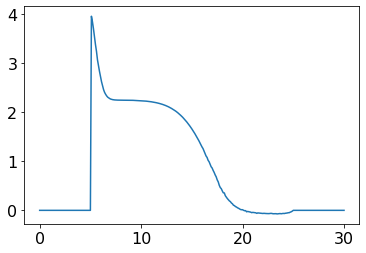

In [110]:
setinitvars(low_state_vars)
max_it = 4
start_step = 1.
alg = "A1"
#control0
#init_1nA_lh

if not plot_only:
    if alg == "A1":
        bestControlH, bestStateH, costH, runtimeH, grad = aln.A1(control0, target_lh, c_scheme, u_mat, u_scheme,
            max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl, t_sim_ = dur,
            t_sim_pre_ = dur_pre, t_sim_post_ = dur_post)
    elif alg == "A2":
        bestControlH, bestStateH, costH, runtimeH = aln.A2(control0, target_lh, max_iteration_ = max_it,
                    tolerance_ = tol, include_timestep_ = incl_step, start_step_ = start_step, test_step_ = test_step,
                    max_control_ = max_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post)

    resultH = {"Opt_control": bestControlH,
              "Opt_state": bestStateH,
              "costArray": costH,
              "runtimeArray": runtimeH,    
    }

    dump_dicts = [opt_params, aln.params, resultH]
    filename = str("H_" + alg + ".p")
    pickle.dump( dump_dicts, open( filename, "wb" ) )

    
plt.plot(np.arange(0,bestControlH.shape[2]*aln.params.dt,aln.params.dt), bestControlH[0,0,:])

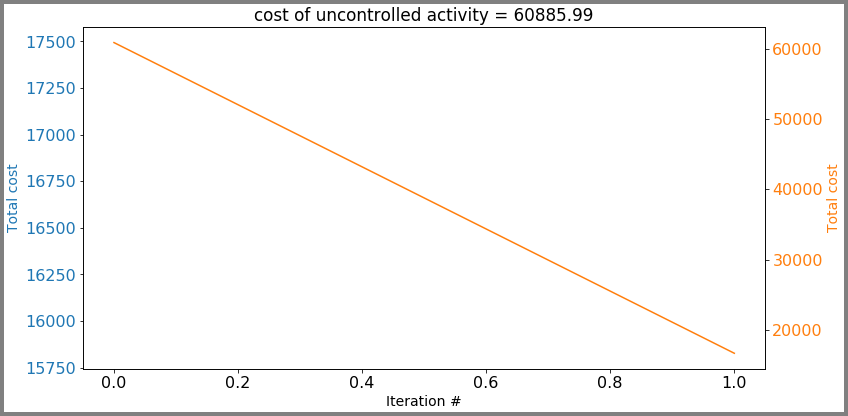

In [9]:
plotFunc.plot_convergence(costH, path, str("p1_e1_u1nA_LowHigh_cost_" + alg) )

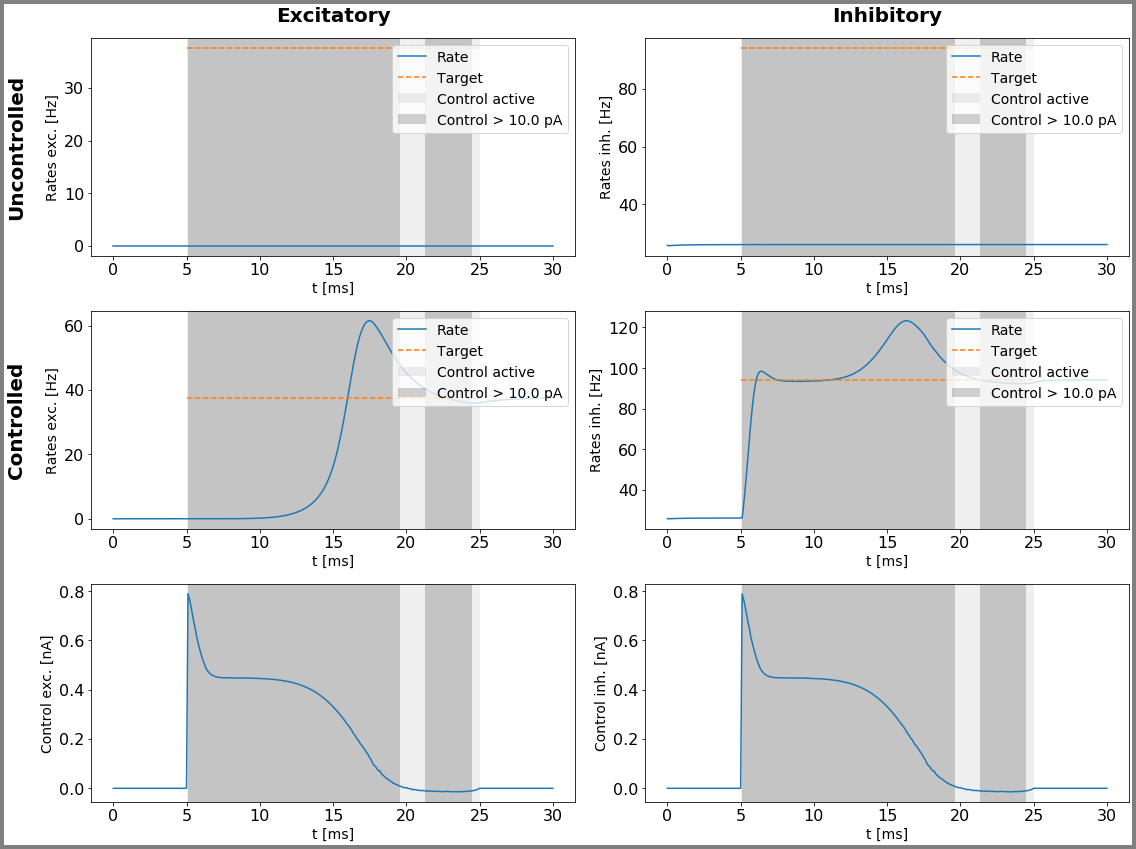

In [111]:
plotFunc.plot_control(aln, bestControlH, dur, dur_pre, dur_post, low_state_vars, target_lh,
                      path, filename_ = str('p1_e1_u1nA_LowHigh_' + alg))

In [136]:
cntrl1 = control0
alg = "A1"

max_it = 20
loop_it = 75
costA1 = np.zeros(max_it*loop_it + 1)
runtimeA1 = np.zeros(max_it*loop_it + 1)

#cntrl1 = cntrlA1_[:,:,50:251]

RUN  0 , total integrated cost =  60885.99150259075
dir =  [[[-0.00000000e+00  1.23778837e+00  1.23259124e+00  1.22737067e+00
    1.22212651e+00  1.21685859e+00  1.21156676e+00  1.20625085e+00
    1.20091073e+00  1.19554625e+00]
  [-0.00000000e+00  2.08476519e+03  2.08477025e+03  2.08477513e+03
    2.08477986e+03  2.08478443e+03  2.08478885e+03  2.08479312e+03
    2.08479724e+03  2.08480123e+03]]]
step size exc =  2.325293484052265
step size inh =  0.001179236672562927
step size =  0.8866553906161165 15754.429424203798
step size =  0.001179236672562927 16660.439163424522
choose separately
RUN  1 , total integrated cost =  15754.429424203798
dir =  [[[ -0.         580.55963995 583.29052383 585.70556317 588.24488488
   590.81659432 593.41295988 595.92774883 598.54939042 601.17338773]
  [ -0.         882.89491835 834.13904561 790.11347208 741.28657324
   694.99469131 627.43202311 576.08857192 512.33697895 441.93871171]]]
step size exc =  7.804094712967007e-05
step size inh =  0.0015463005

step size exc =  0.0007383149715520456
step size inh =  0.001594983671683292
step size =  1.0499917533371803 6990.835209960112
step size =  0.0008067767039191522 7007.400358137819
choose separately
RUN  16 , total integrated cost =  6990.835209960112
dir =  [[[  -0.          643.18751967  646.21438073  648.22847901  650.70850153
    653.43377834  656.13107306  659.01800372  661.93592863  664.91047528]
  [  -0.          125.66709016   63.39796694   -8.75379472  -80.96182071
   -104.76203895  -81.27912441  -56.06551349  -39.91413014  -33.44070156]]]
step size exc =  8.078256784285619e-05
step size inh =  0.0016836869708923739
step size =  0.9191261052342747 6843.664996542291
step size =  8.078256784285619e-05 6841.201635729085
choose joint computation
RUN  17 , total integrated cost =  6841.201635729085
dir =  [[[ -0.          38.35171403  38.53185176  38.65157932  38.79851463
    38.96025626  39.12074918  39.29174055  39.46397874  39.63962795]
  [ -0.         164.63935827 100.99176472  

ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


step size =  0.0007819752567188481 6108.494092168072
choose joint computation
RUN  20 , total integrated cost =  6108.494092168072
Improved over  20  iterations by  89.96732427046351  percent.
max value of final gradient at index =  (array([0], dtype=int64), array([0], dtype=int64), array([96], dtype=int64)) 357.39137122743386
min value of final gradient at index =  (array([0], dtype=int64), array([1], dtype=int64), array([1], dtype=int64)) -162.25322722176475
Problem in initial value trasfer for  sigmae_f
1.518235957096325
1.5182355652160797
Problem in initial value trasfer for  sigmai_f
1.501909936524541
1.5019098897679062
Problem in initial value trasfer for  tau_exc
21.356780408292302
21.356841639083466
Problem in initial value trasfer for  tau_inh
2.33029094029334
2.330218472786663
RUN  0 , total integrated cost =  6108.620235468129
dir =  [[[ -0.         444.28232178 446.37276329 447.73714716 449.44301725
   451.33410716 453.24846159 455.25037879 457.26991621 459.09626037]
  [ -0

step size =  0.0035498174972442694 4632.730461857187
choose separately
RUN  14 , total integrated cost =  4626.01731302982
dir =  [[[ -0.         380.29360854 381.94930795 383.04245207 384.49549377
   386.05623991 387.77416834 389.48951442 391.11602175 392.86830781]
  [ -0.          83.43278166  24.75894644 -52.89045174 -68.40059561
   -41.94557018 -24.65372818 -22.57376511 -25.15249228 -28.0317614 ]]]
step size exc =  0.00015816651632662778
step size inh =  0.0016081891156952794
step size =  1.3456925306735017 4467.740274276218
step size =  0.00017254529053813941 4541.2059299770335
choose separately
RUN  15 , total integrated cost =  4467.740274276218
dir =  [[[ -0.          35.96829525  36.12349596  36.22563305  36.36204163
    36.50941469  36.66966697  36.82952795  36.9829418   37.14308529]
  [ -0.         108.41431719  53.80243252  -0.58670134  -3.06795911
    28.42804133  41.46210213  41.83359229  38.71537031  36.32315937]]]
step size exc =  0.003323920020146907
step size inh =  0

...

RUN  0 , total integrated cost =  997.4709063406235
dir =  [[[ -0.          14.36451174  14.32405664  14.04578912  13.33389157
    10.75378771   5.29942492  -3.99241042 -16.44622582 -17.33428538]
  [ -0.          12.40431138  -2.05143956   1.68367775   1.76267273
     2.03548782   2.18586617   1.91823669   0.71259273  -1.71945177]]]
step size exc =  0.0010807818260000811
step size inh =  0.002598269488632047
step size =  0.9237545908394856 997.2566322171232
step size =  0.001113145693937417 997.2677399519955
choose separately
RUN  1 , total integrated cost =  997.2566322171232
dir =  [[[ -0.          13.04287688  13.00565818  12.74893877  12.07504479
     9.59384953   4.26109624  -4.98811904 -17.59728161 -19.07689308]
  [ -0.          12.25602157  -2.70972003   0.61542026   0.52517629
     0.74707781   0.99328595   0.98926814   0.20440811  -1.75141668]]]
step size exc =  0.0010187405278537856
step size inh =  0.0025393816664085076
step size =  0.9222177917410314 997.062834723102
step s

dir =  [[[ -0.          11.83913968  11.80479883  11.56865384  10.93251694
     8.53857535   2.90540096  -6.30836874 -18.89226381 -20.00470833]
  [ -0.          11.43023048  -2.86129241  -0.13011043  -0.39570703
    -0.41694078  -0.37804612  -0.25618672  -0.17675291  -0.43489517]]]
step size exc =  0.0008991531578585914
step size inh =  0.002373828863291814
step size =  0.8953570793602246 994.6128557340204
step size =  0.0009065975705476398 994.6196376296058
choose separately
RUN  16 , total integrated cost =  994.6128557340204
dir =  [[[ -0.          10.46567713  10.43468472  10.22054641   9.62227227
     7.3273019    1.81502115  -7.34747342 -20.10506308 -22.00450307]
  [ -0.          11.49306152  -2.52195728   0.31151701   0.09242625
     0.10160441   0.1532433    0.27092852   0.34506126   0.10211188]]]
step size exc =  0.0013336239637358638
step size inh =  0.003042188446160384
step size =  0.9222177917410314 994.439251654442
step size =  0.0013358463369360985 994.442856289443
choos

ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


step size =  0.0008241796095887636 993.9322232657752
choose separately
RUN  20 , total integrated cost =  993.9249969475552
Improved over  20  iterations by  0.35549000682907206  percent.
max value of final gradient at index =  (array([0], dtype=int64), array([0], dtype=int64), array([9], dtype=int64)) 19.742300994747794
min value of final gradient at index =  (array([0], dtype=int64), array([0], dtype=int64), array([1], dtype=int64)) -11.591109225530758
Problem in initial value trasfer for  sigmae_f
1.518235957096325
1.5182355652160797
Problem in initial value trasfer for  sigmai_f
1.501909936524541
1.5019098897679062
Problem in initial value trasfer for  tau_exc
21.356780408292302
21.356841639083466
Problem in initial value trasfer for  tau_inh
2.33029094029334
2.330218472786663


D:\Promotion\neurolib\neurolib\utils\plotFunctions.py:108: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`).
  fig, ax = plt.subplots(3, columns, figsize=(16, 12), linewidth=8, edgecolor='grey')


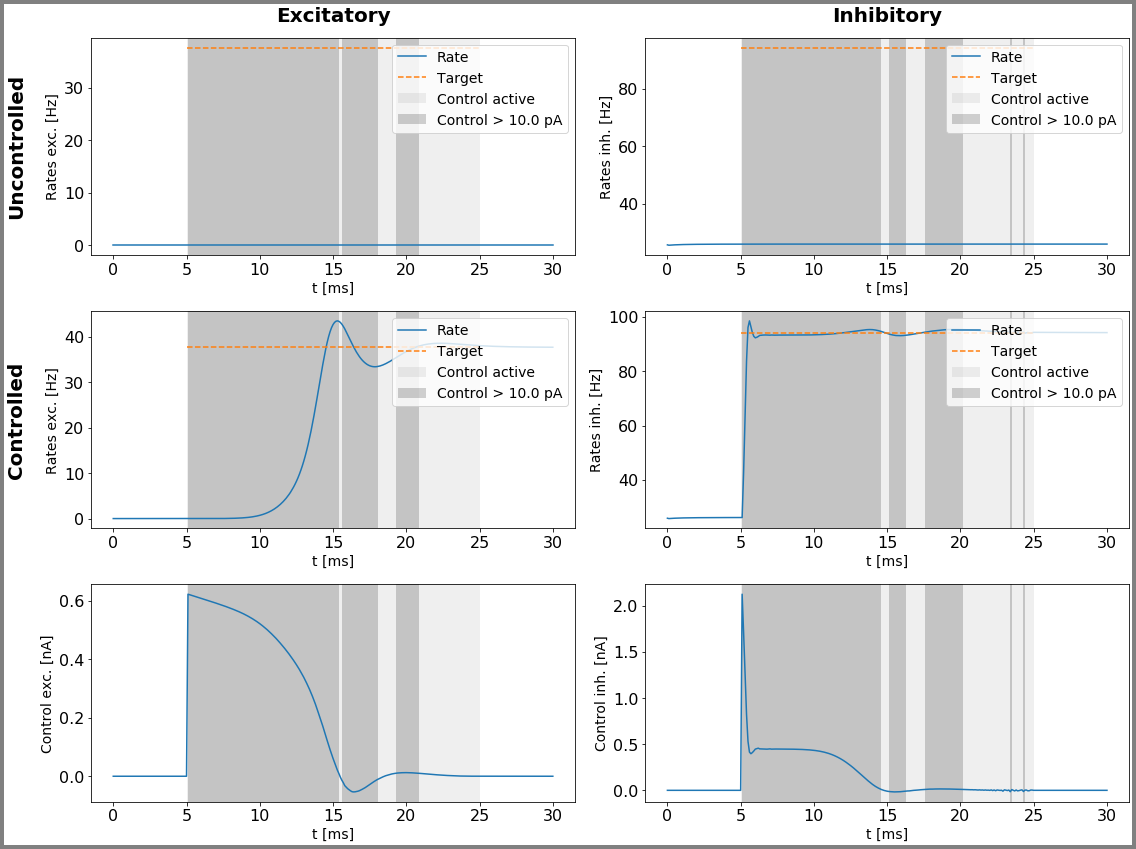

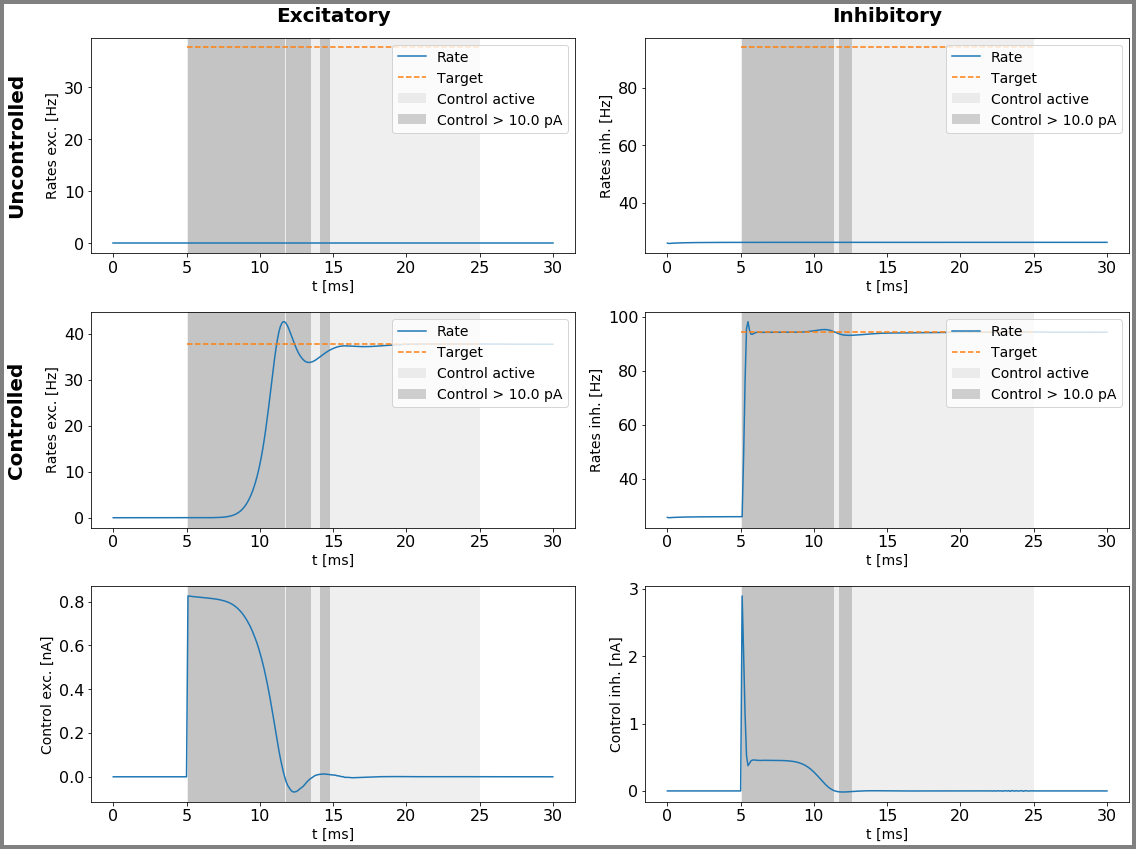

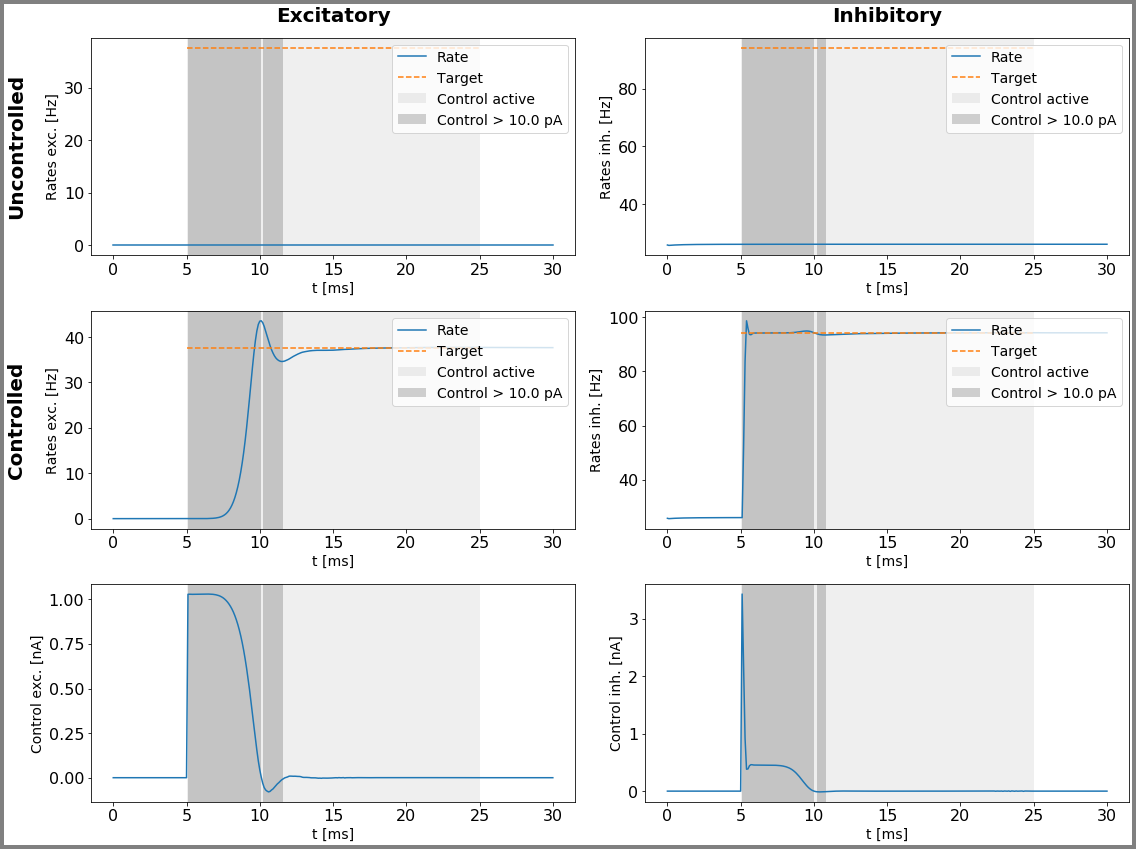

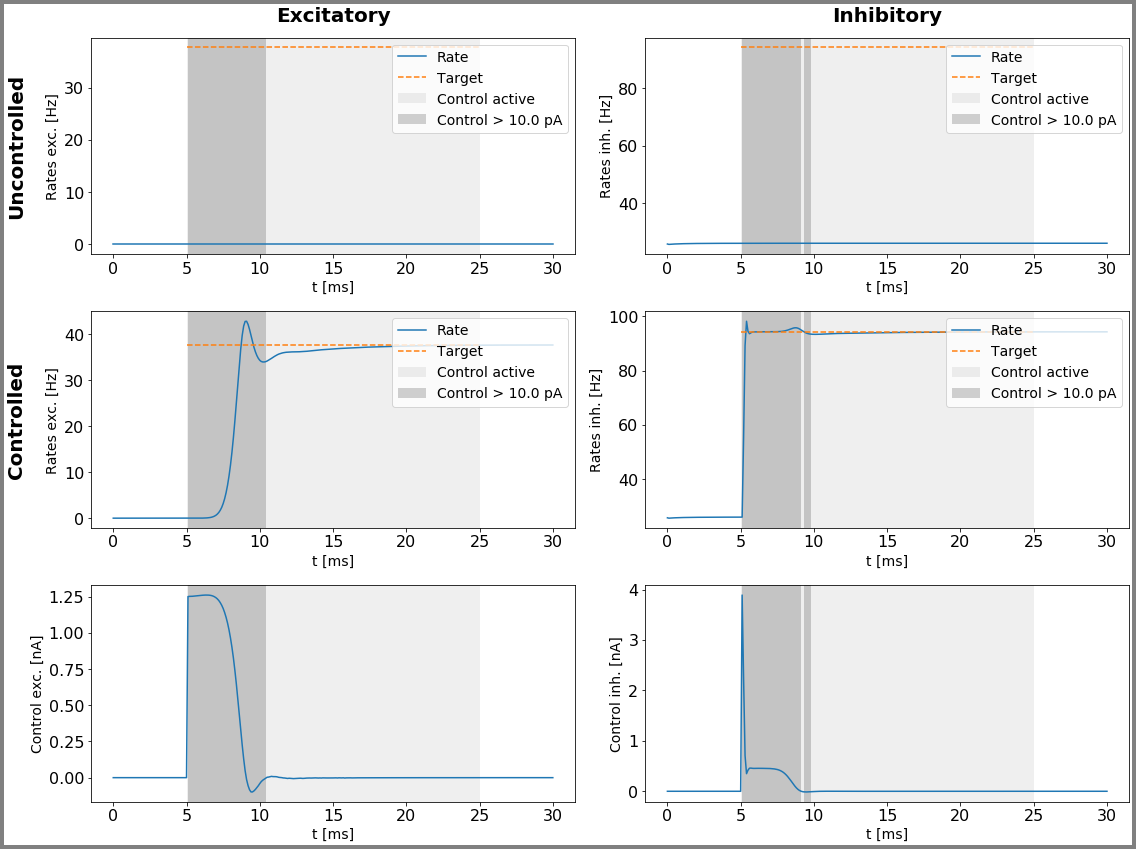

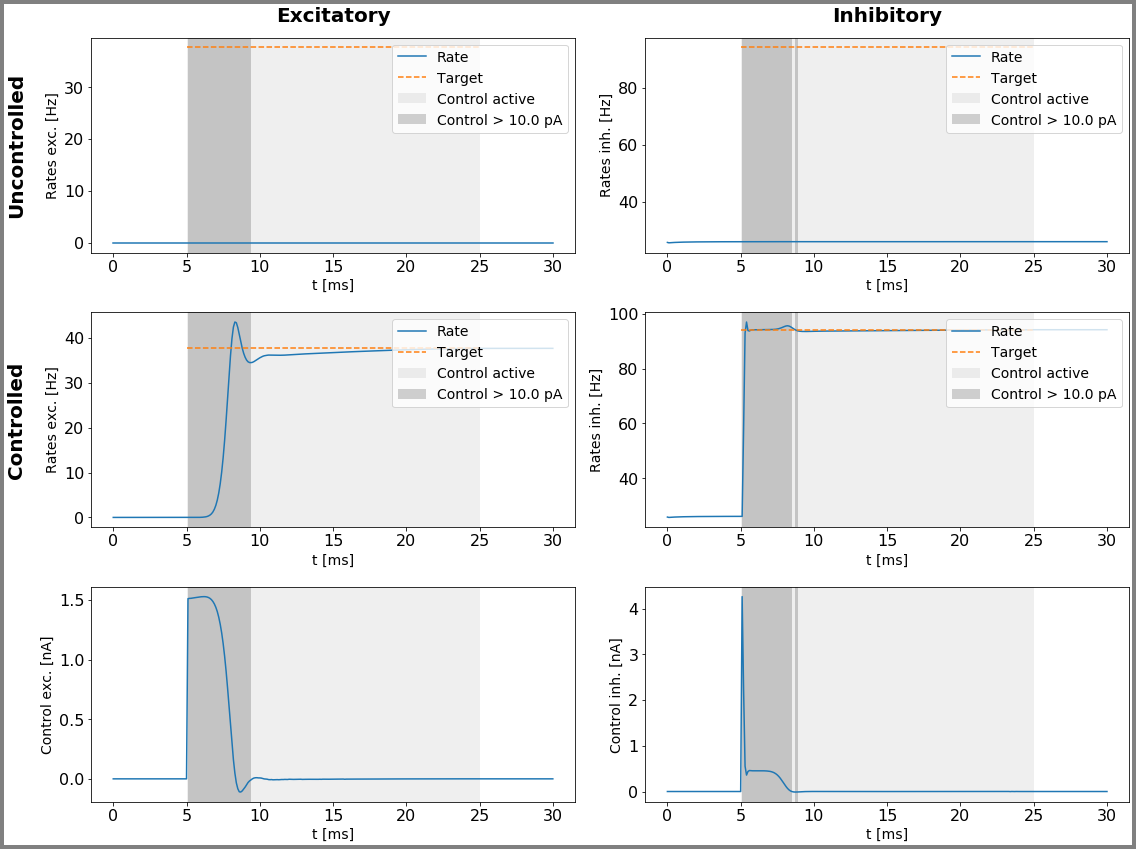

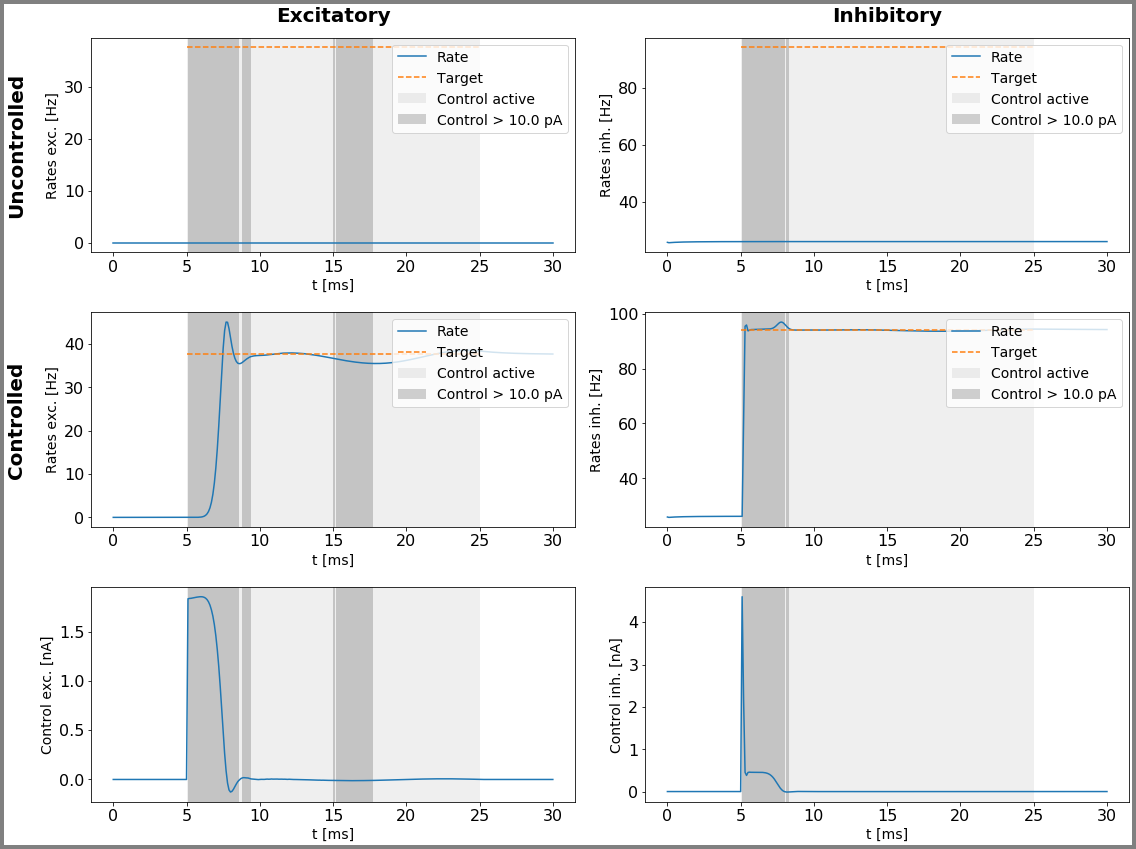

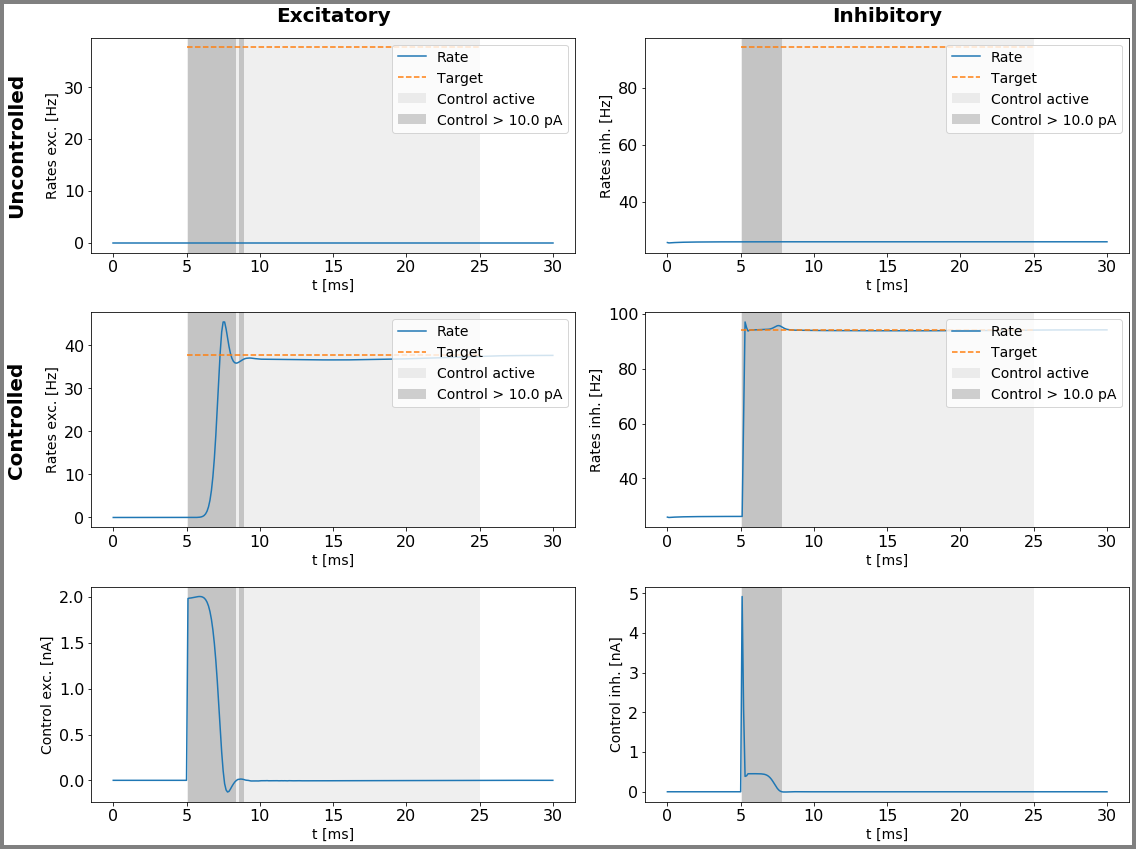

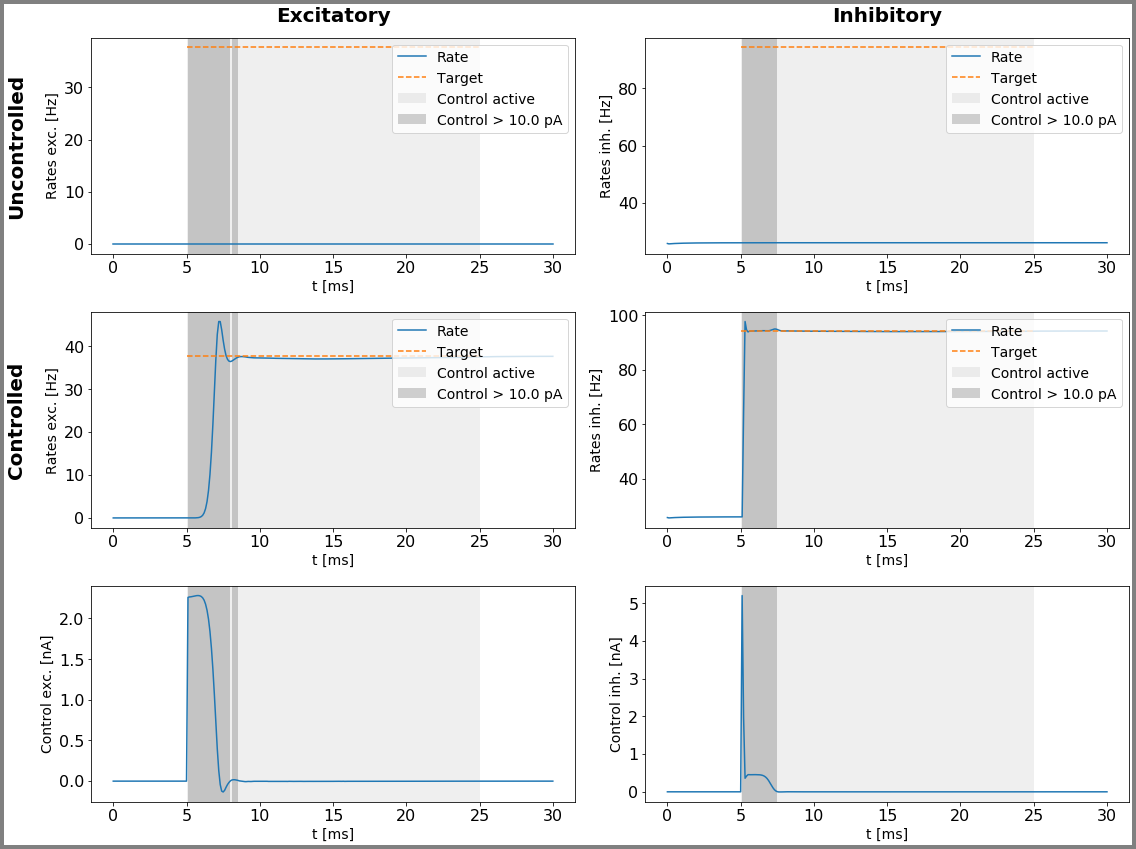

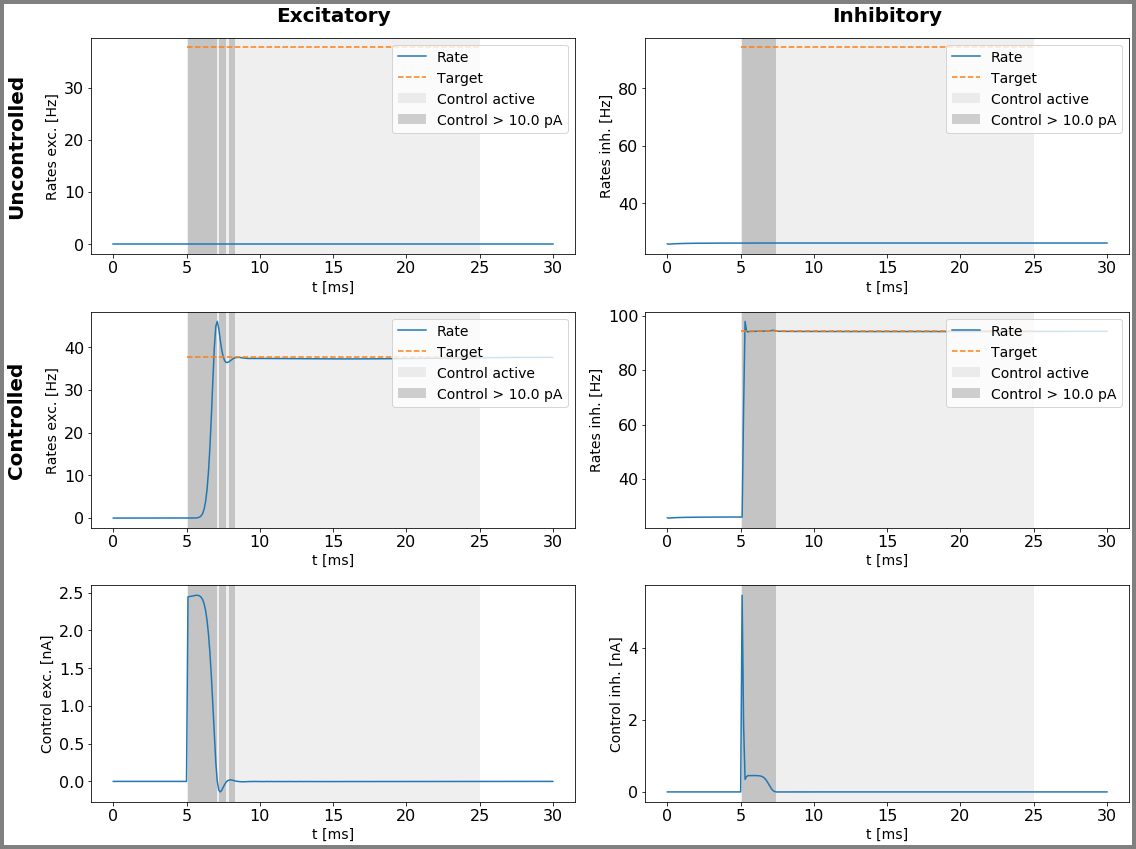

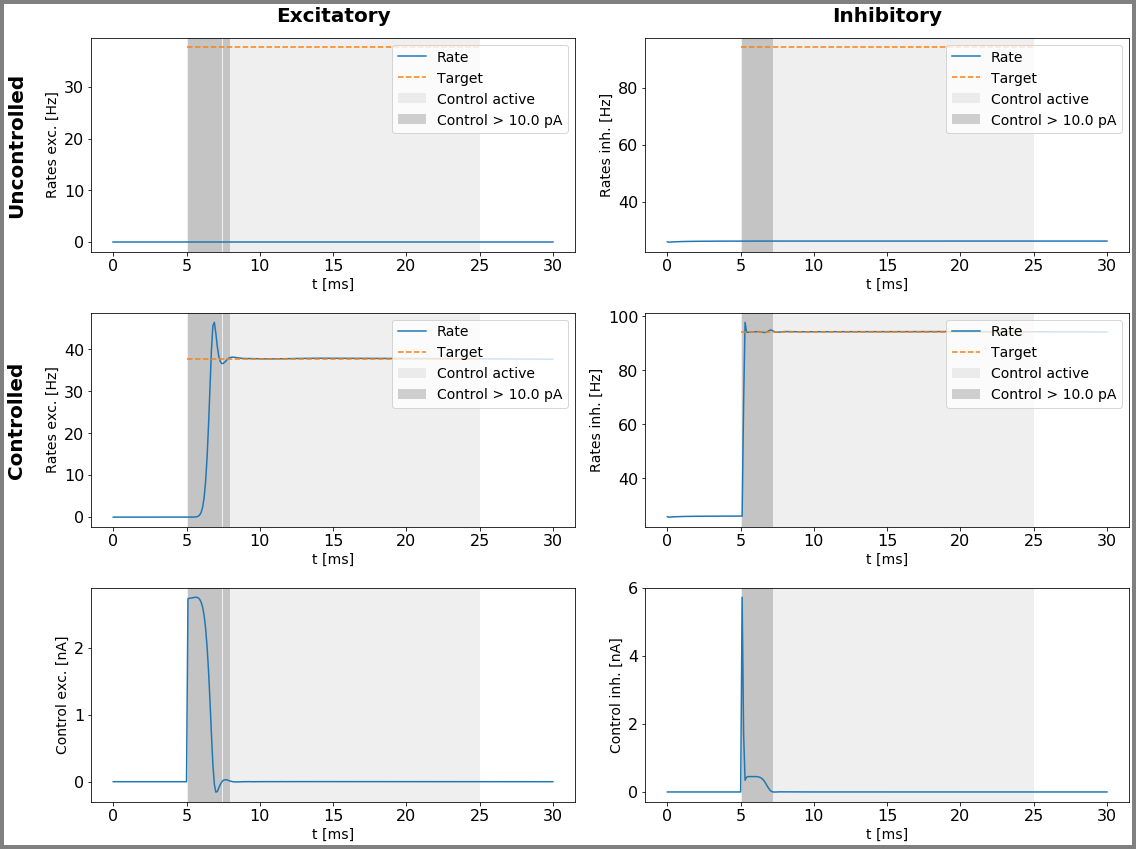

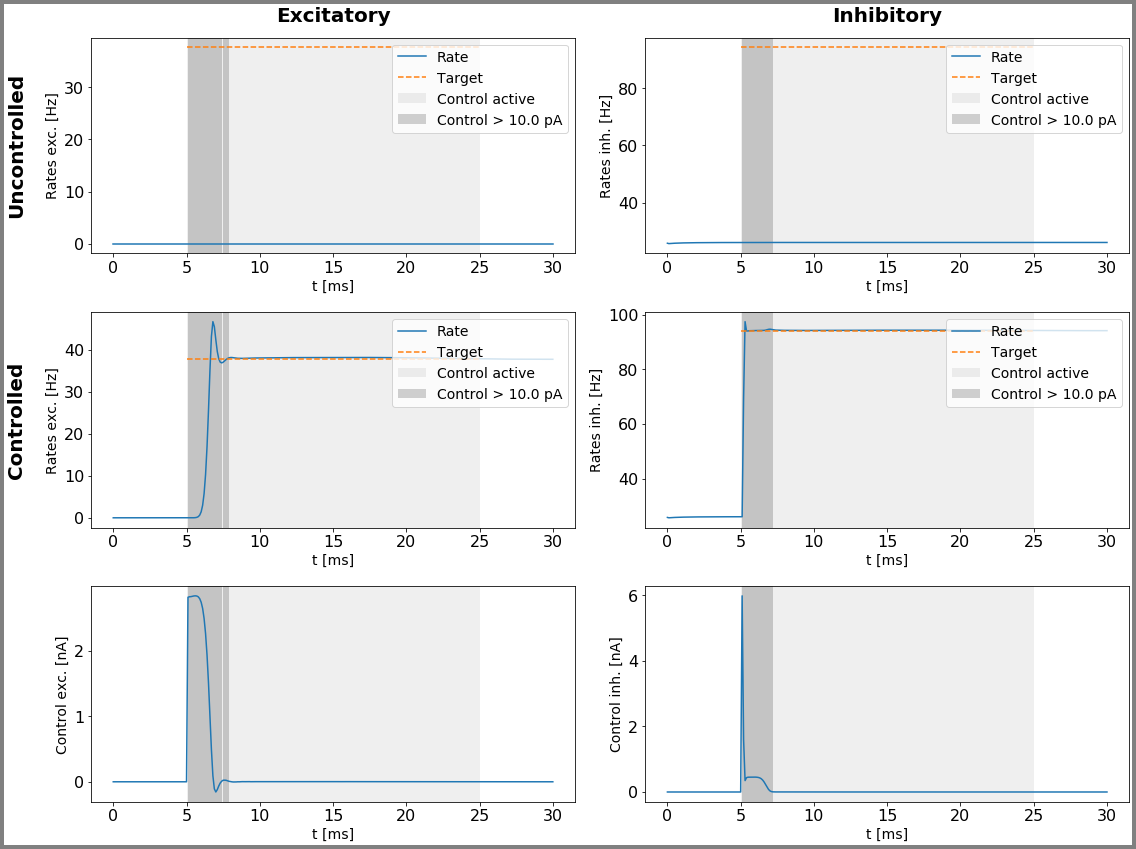

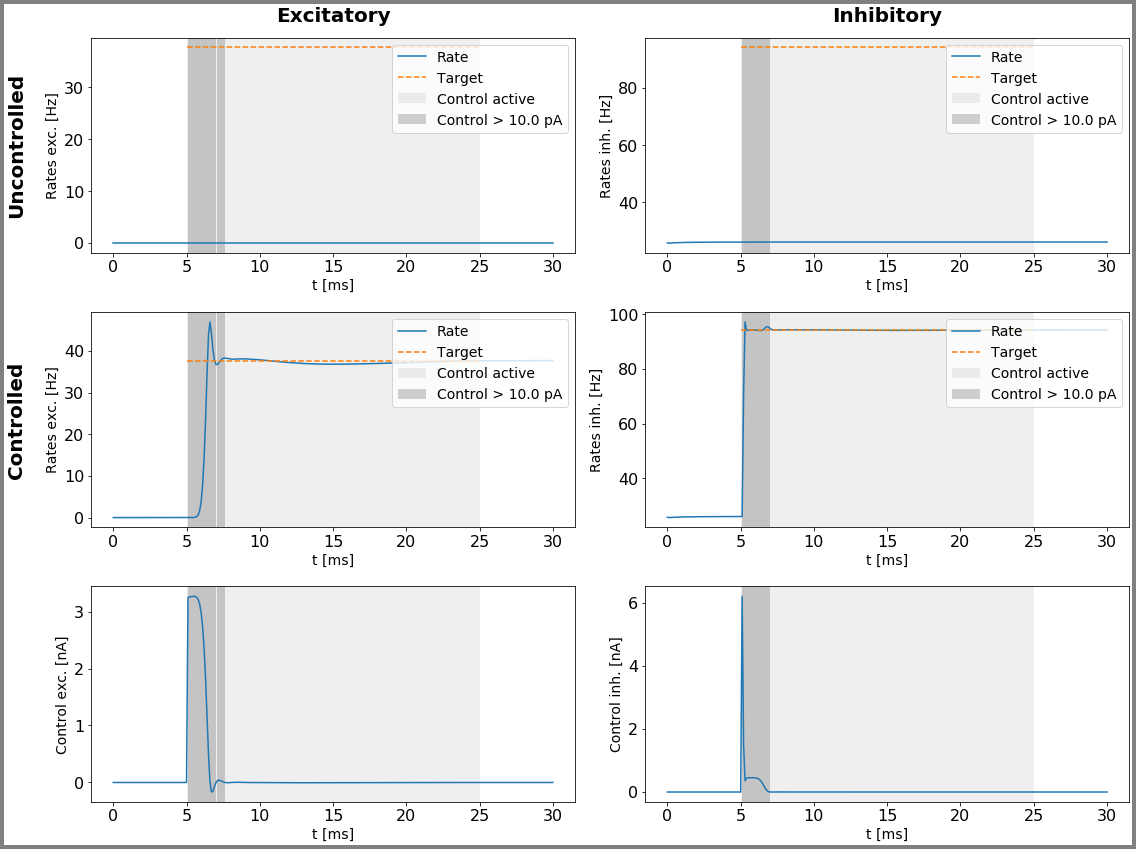

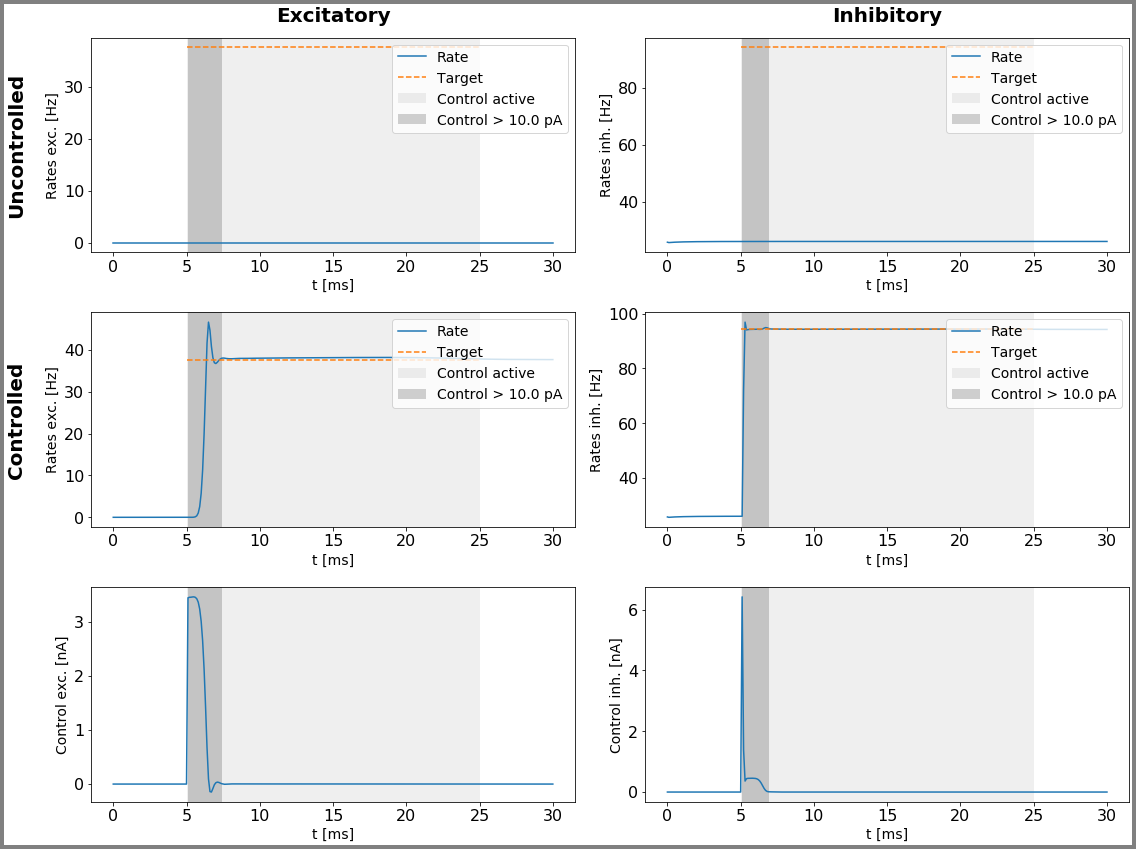

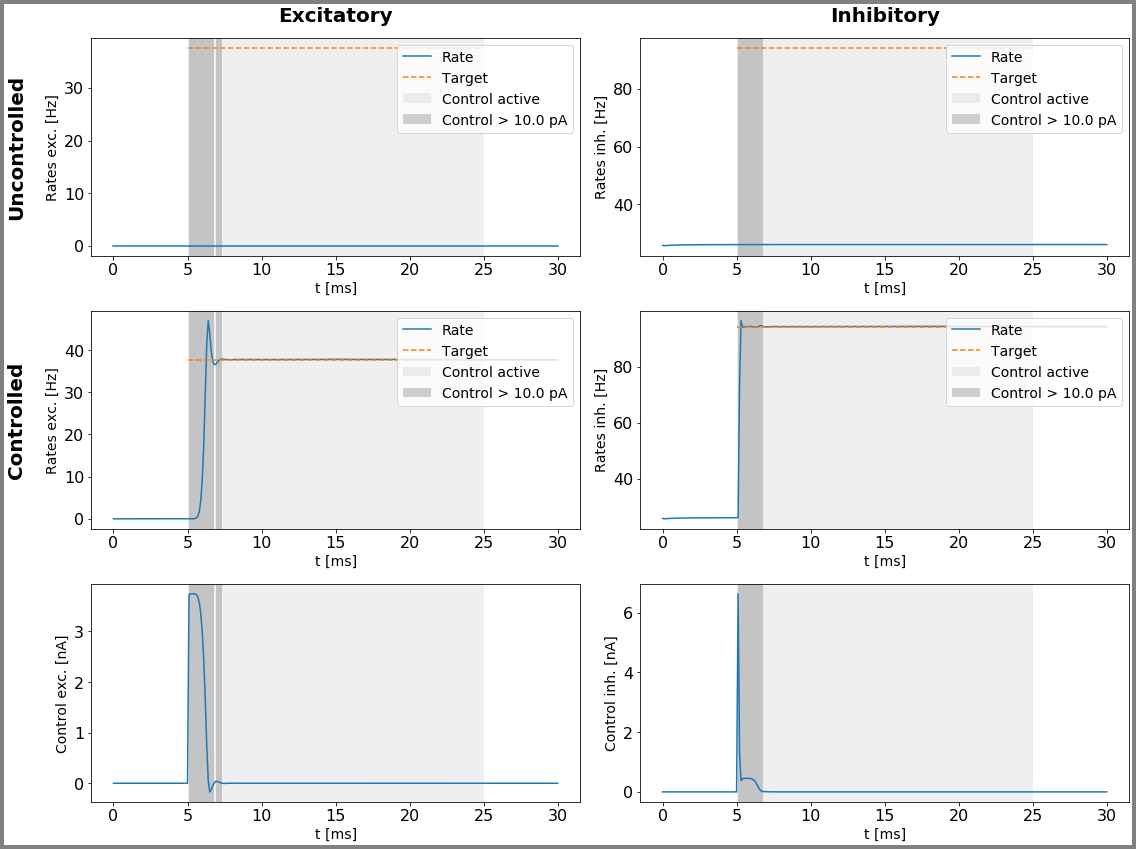

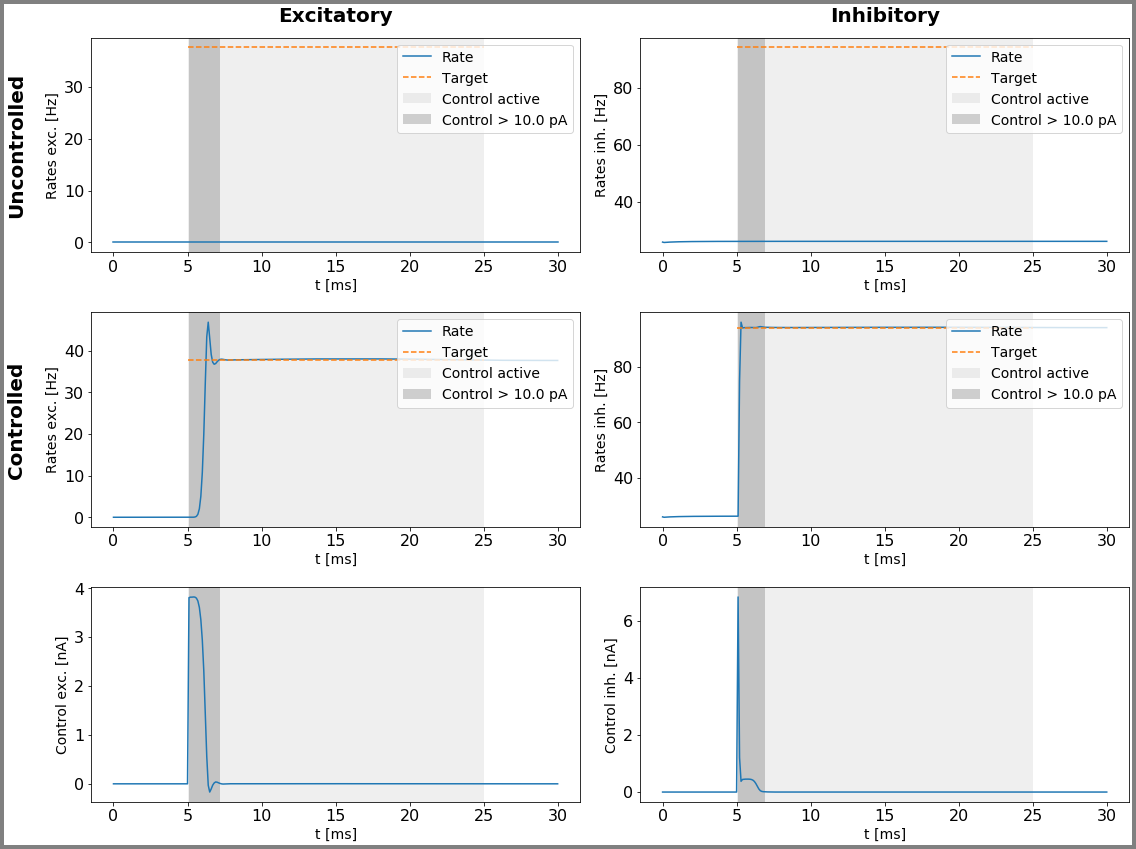

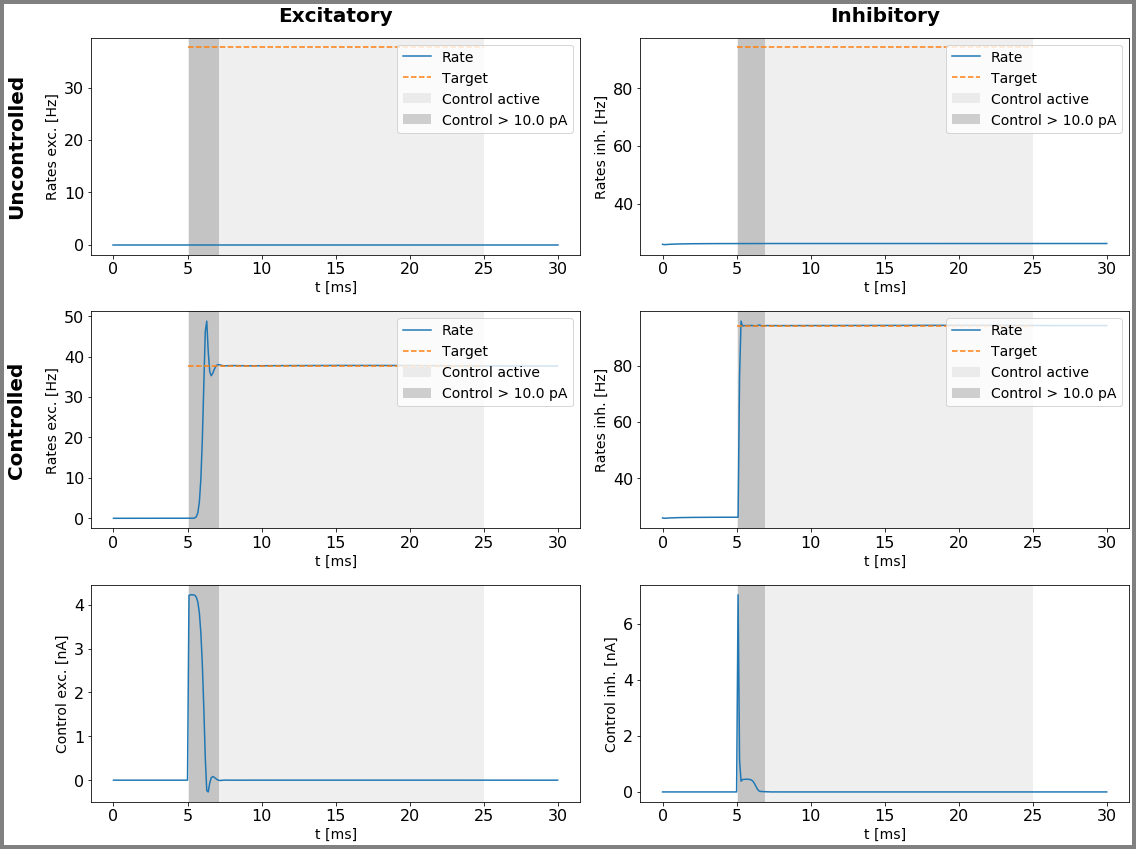

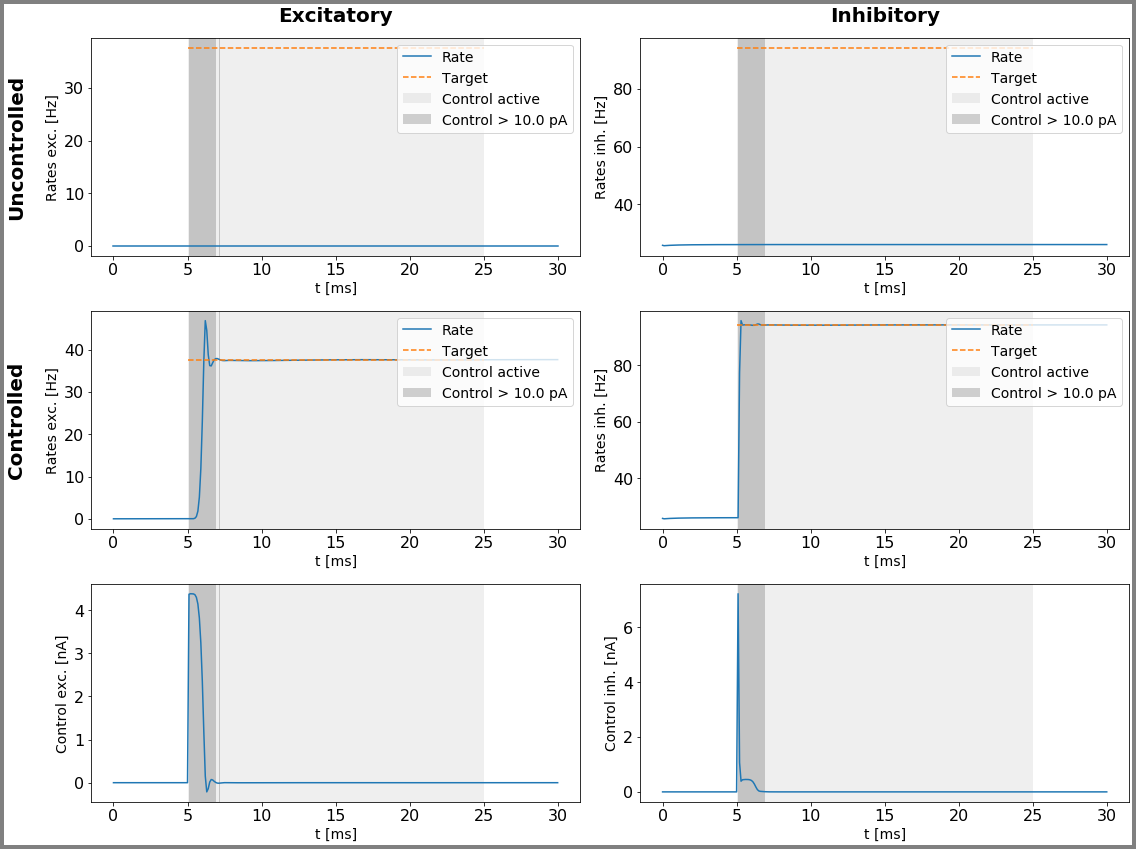

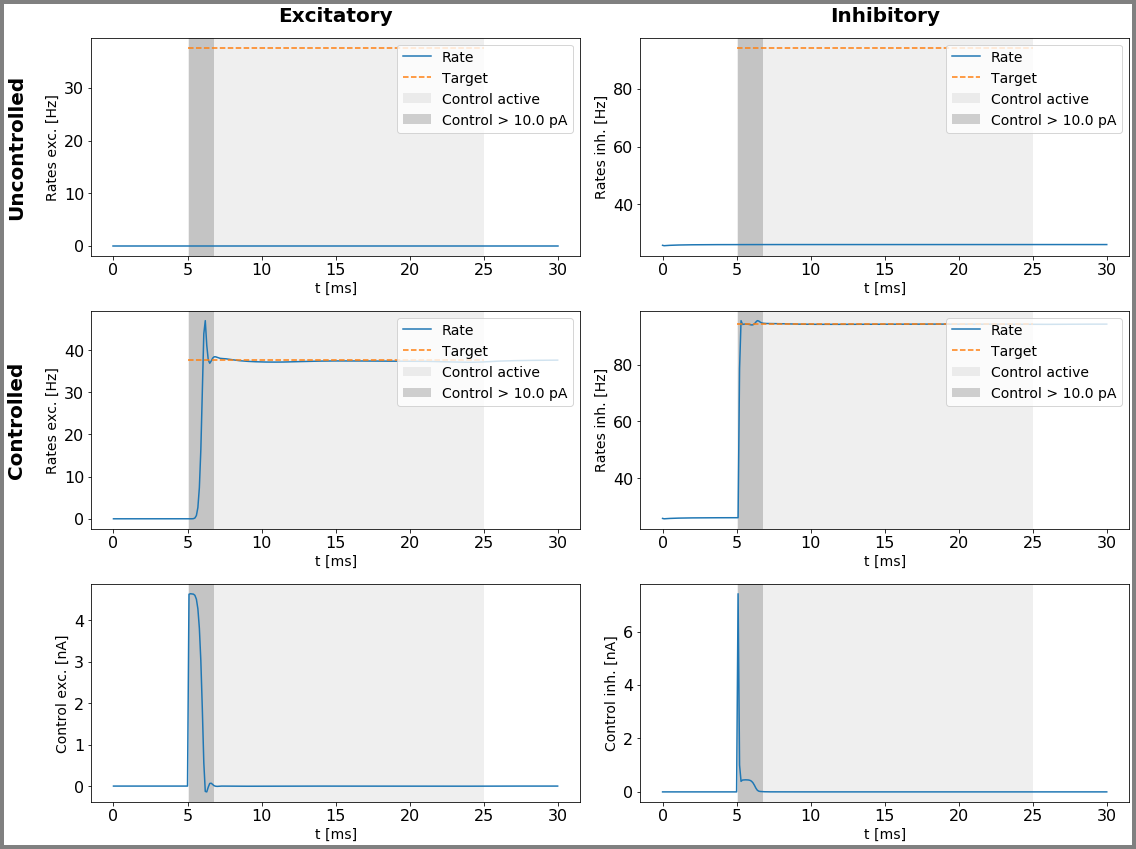

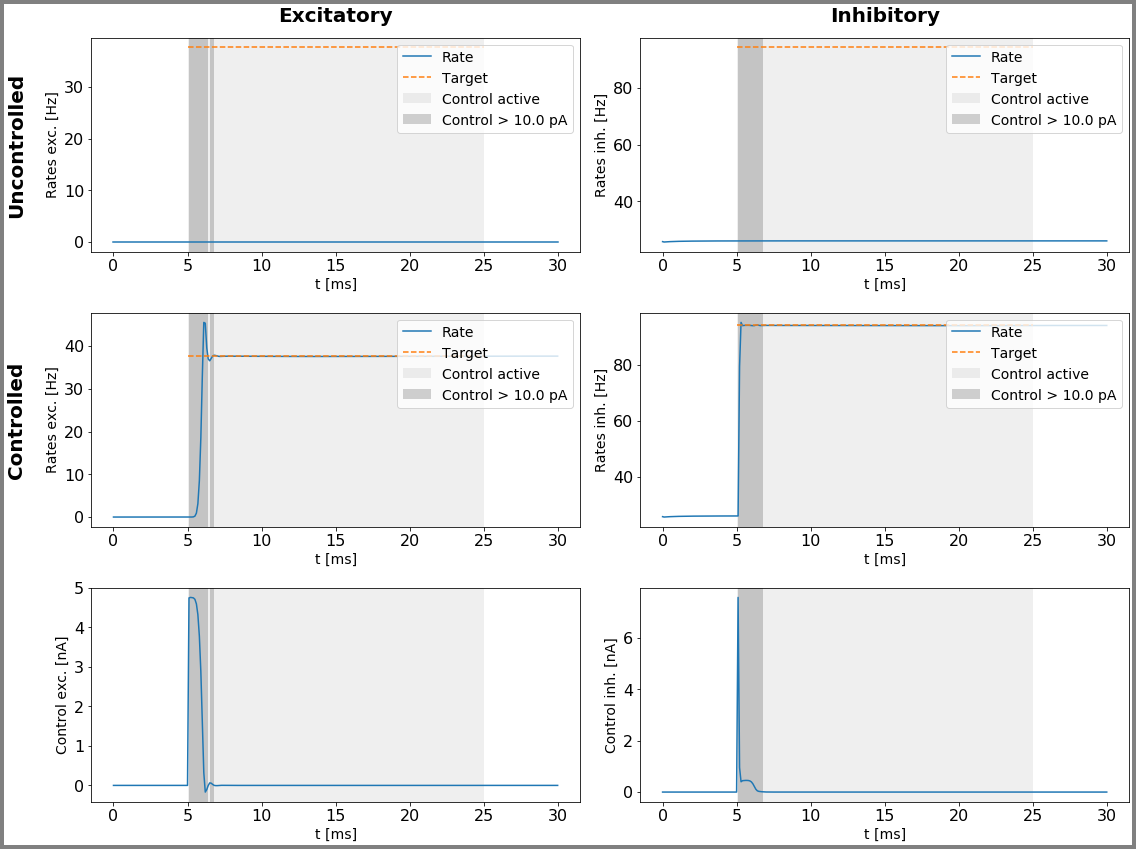

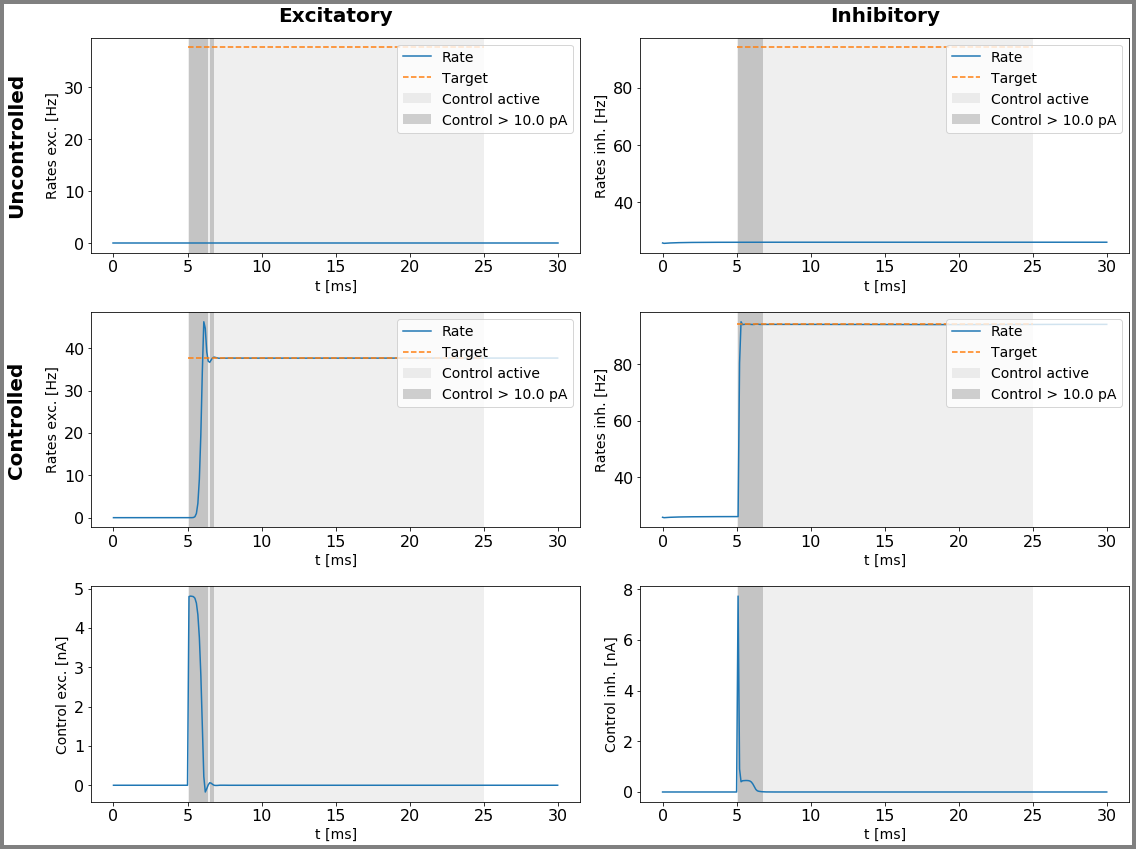

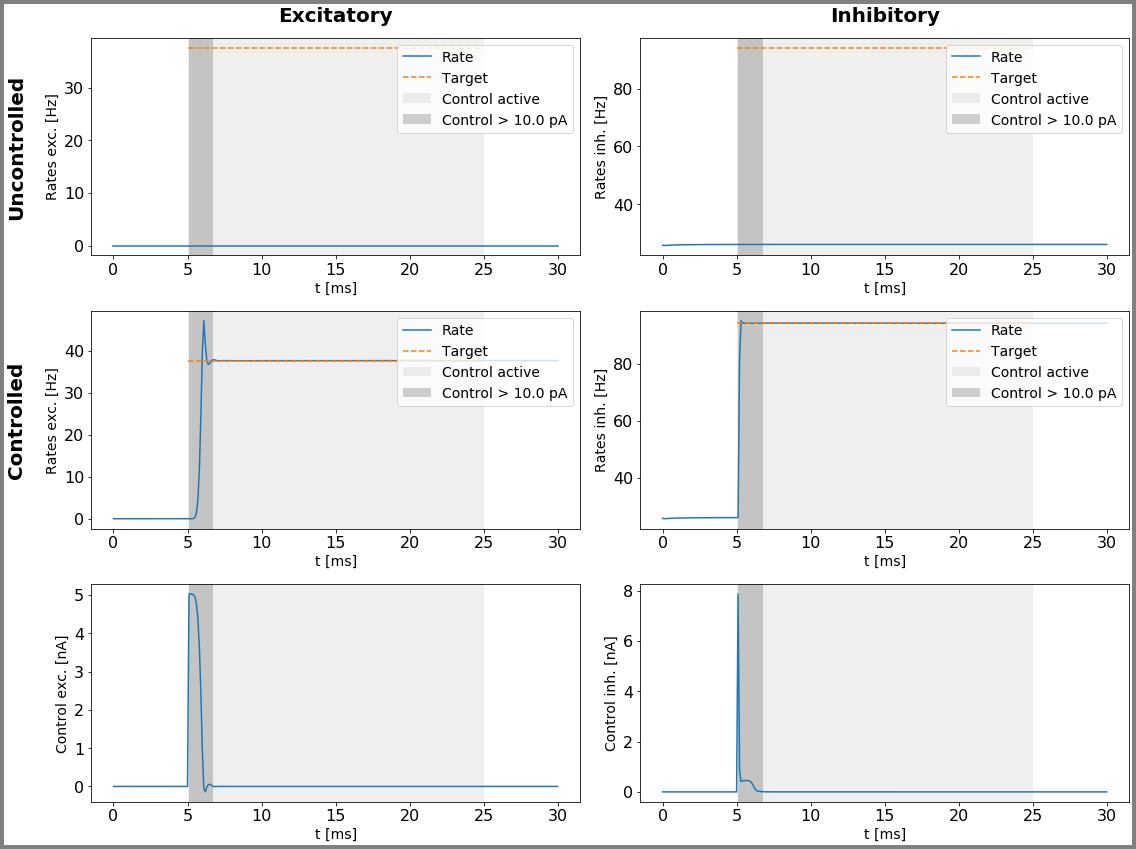

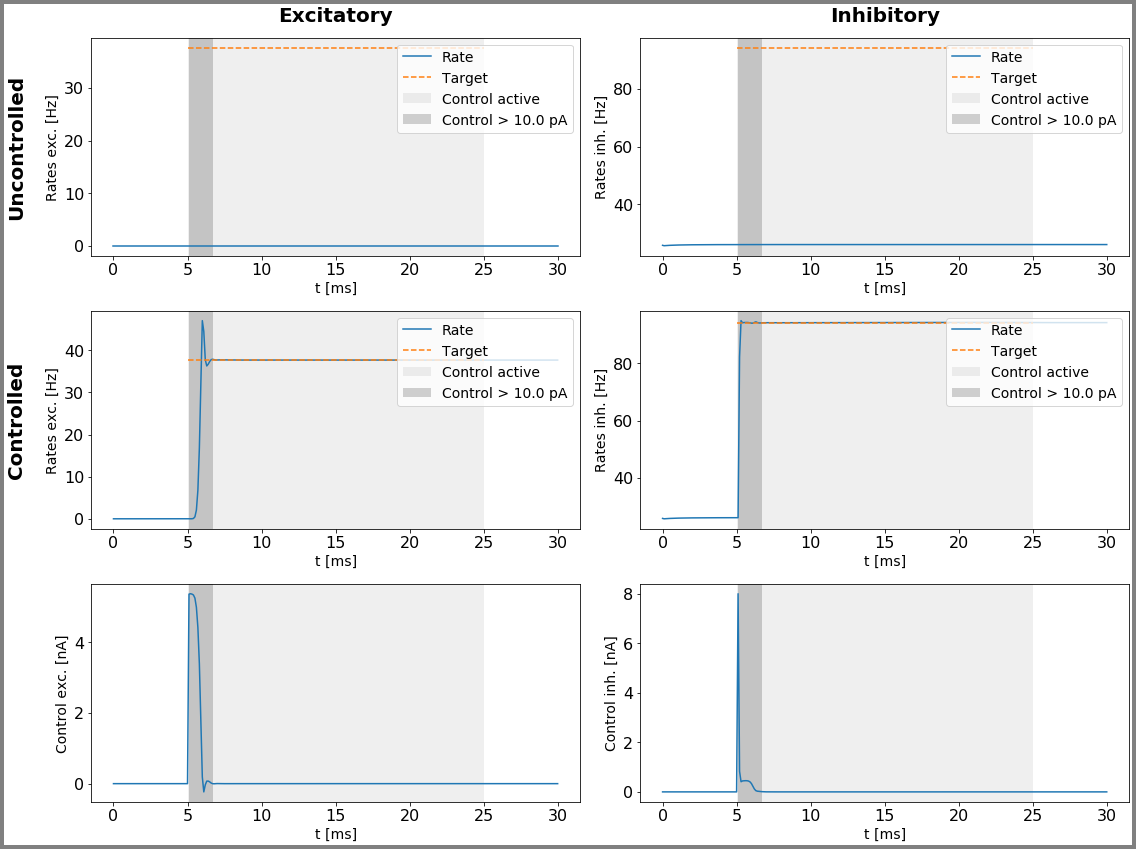

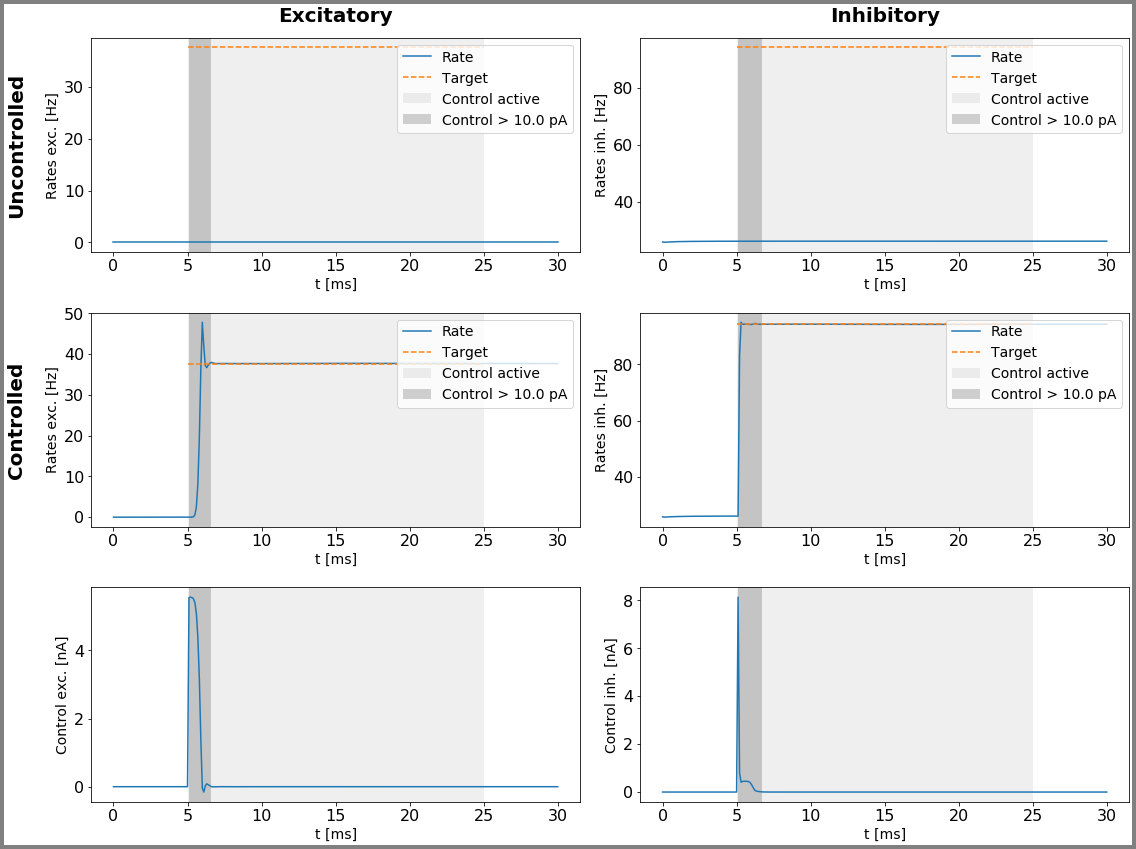

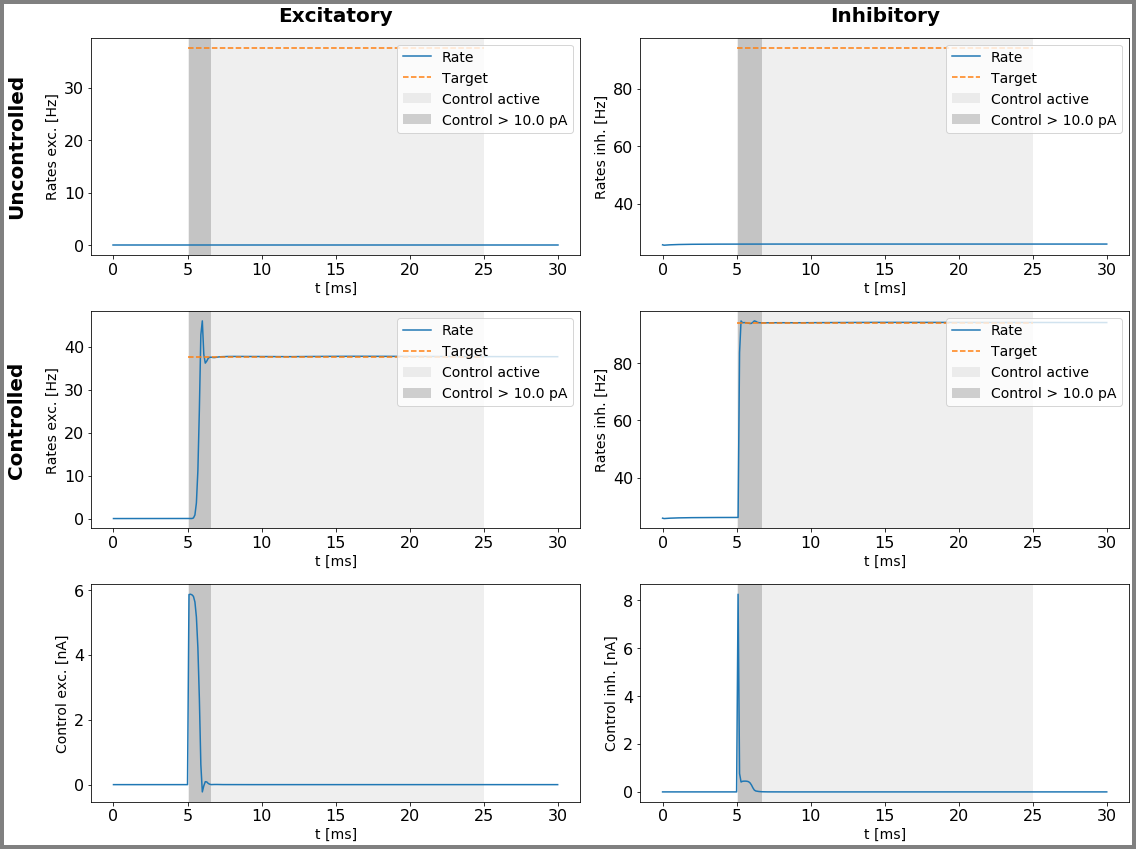

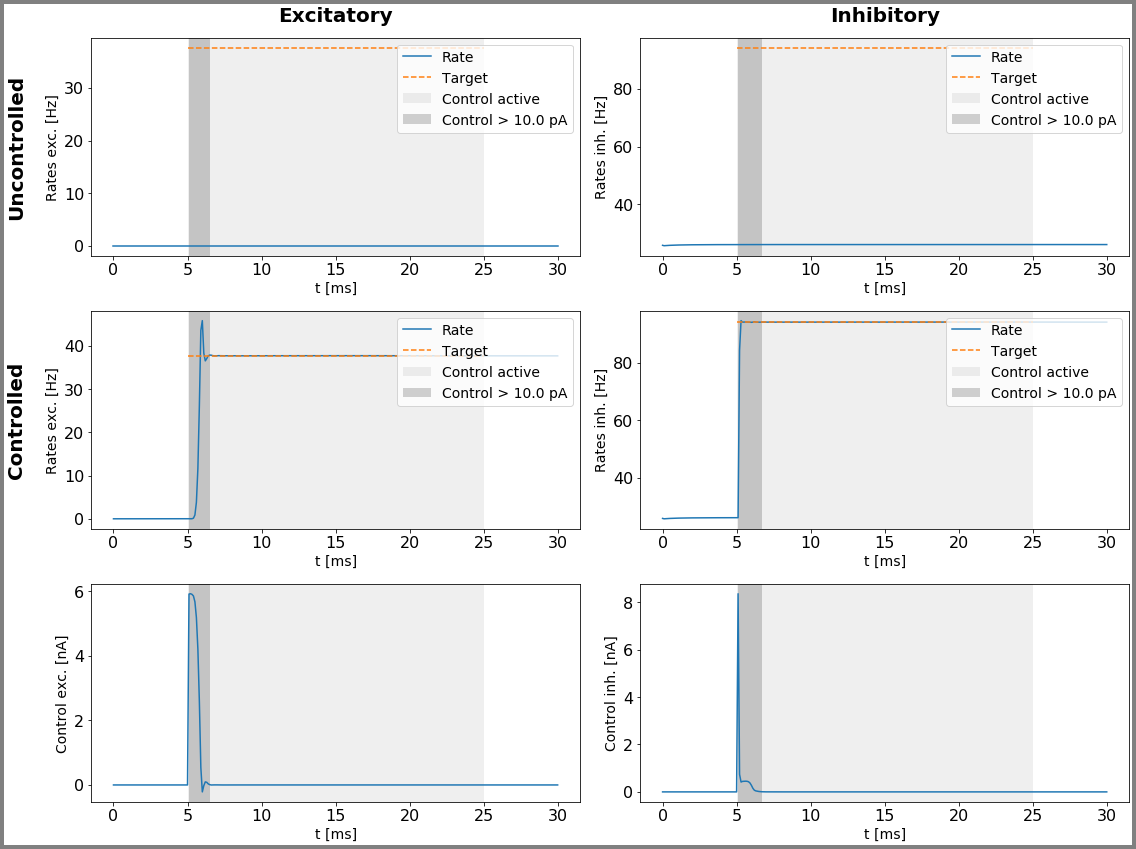

In [137]:
for i in range(50,loop_it):
    setinitvars(low_state_vars)
    
    cntrlA1_, bestStateA1_, costA1_, runtimeA1_, grad = aln.A1(cntrl1, target_lh, c_scheme, u_mat, u_scheme,
            max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl, t_sim_ = dur,
            t_sim_pre_ = dur_pre, t_sim_post_ = dur_post)
    
    #if (i % 10 == 0):
    plotFunc.plot_control(aln, cntrlA1_, dur, dur_pre, dur_post, low_state_vars, target_lh,
                      path, filename_ = str('p1_e1_u1nA_LowHigh_' + alg + "_" + str(i*max_it) ))
    
    cntrl1 = cntrlA1_[:,:,50:251]
    if i == 0:
        costA1[0] = costA1_[0]
    costA1[max_it*i+1:max_it*i+max_it+1] = costA1_[1:]
    runtimeA1[max_it*i+1:max_it*i+max_it+1] = runtimeA1[max_it*i] + runtimeA1_[1:]

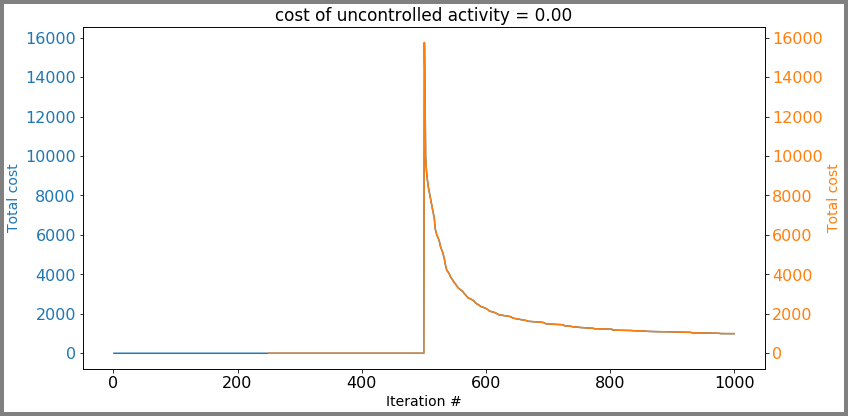

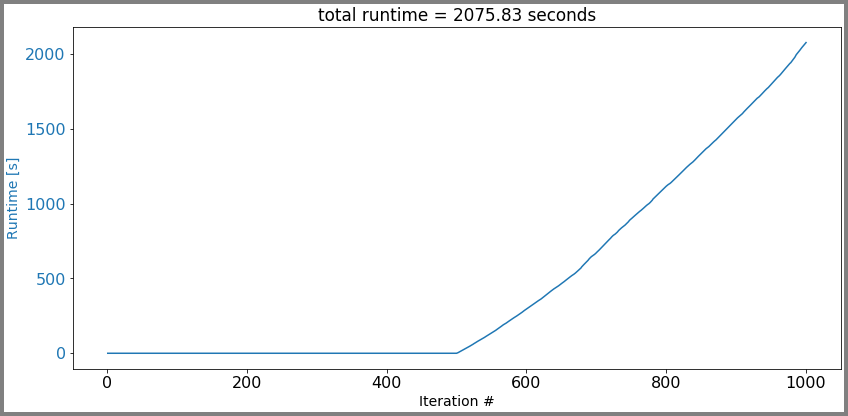

In [135]:
#print(costA1)
#print(costD)
costA1 = np.array(costA1[:])
#print(runtimeA1)
runtimeA1 = np.array(runtimeA1[:])
plotFunc.plot_convergence(costA1, path, str("p1_e1_u1nA_LowHigh_cost_" + alg) )
plotFunc.plot_runtime(runtimeA1, path, str("p1_e1_u1nA_LowHigh_runtime_" + alg))

In [14]:
cntrl1 = control0
alg = "A2"

max_it = 5
loop_it = 5
costA2 = np.zeros(max_it*loop_it + 1)
runtimeA2 = np.zeros(max_it*loop_it + 1)

True
RUN  0 , total integrated cost:  60885.99150259075
RUN  1 , total integrated cost:  876.7873529952077
RUN  2 , total integrated cost:  728.3806605975923
RUN  3 , total integrated cost:  723.2652275812694
RUN  4 , total integrated cost:  719.9069116337398
RUN  5 , total integrated cost:  717.7227827068245
Improved over  5  iterations by  99  percent.
True
RUN  0 , total integrated cost:  717.7227827068245
RUN  1 , total integrated cost:  716.3247861762329
RUN  2 , total integrated cost:  715.3390067276707
RUN  3 , total integrated cost:  714.5017380619031
RUN  4 , total integrated cost:  713.9721550384309
RUN  5 , total integrated cost:  713.5311775283366
Improved over  5  iterations by  1  percent.
True
RUN  0 , total integrated cost:  713.5311775283366
RUN  1 , total integrated cost:  713.141127688988
RUN  2 , total integrated cost:  712.7657523760555
RUN  3 , total integrated cost:  712.3868667982479
RUN  4 , total integrated cost:  711.9921525210007
RUN  5 , total integrated co

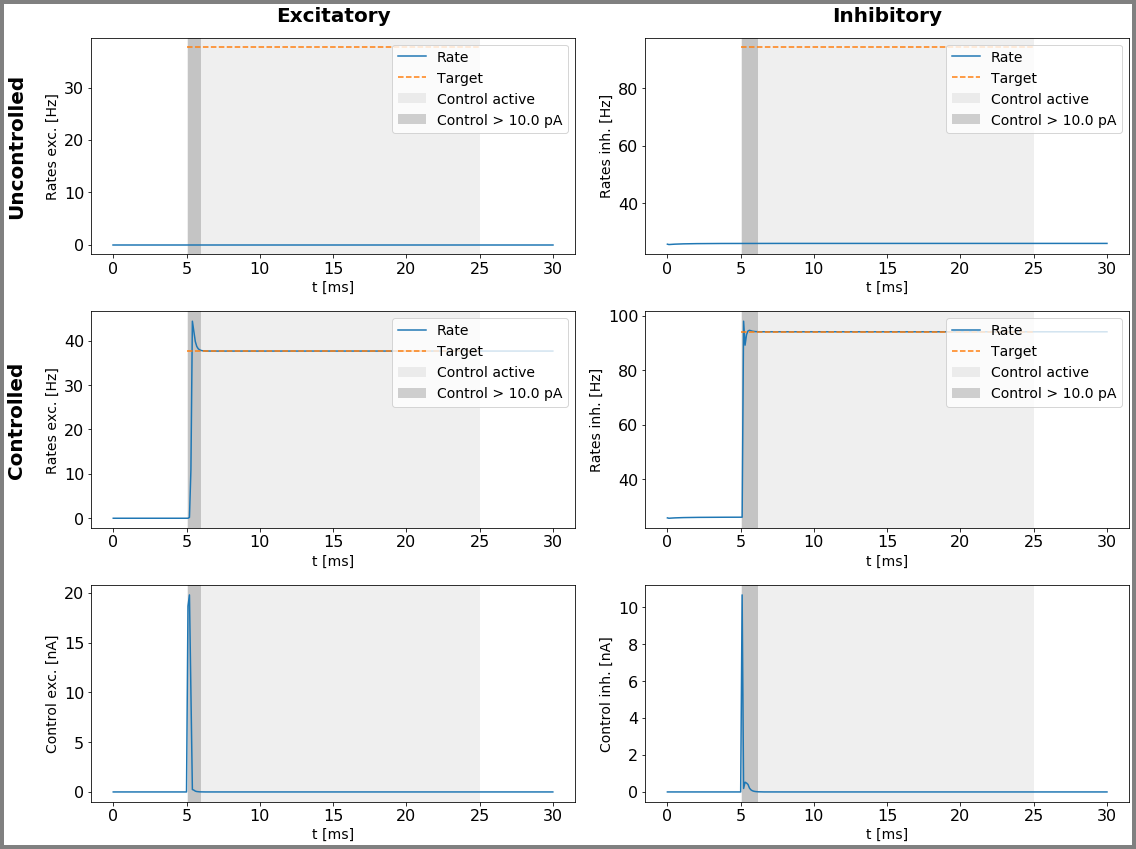

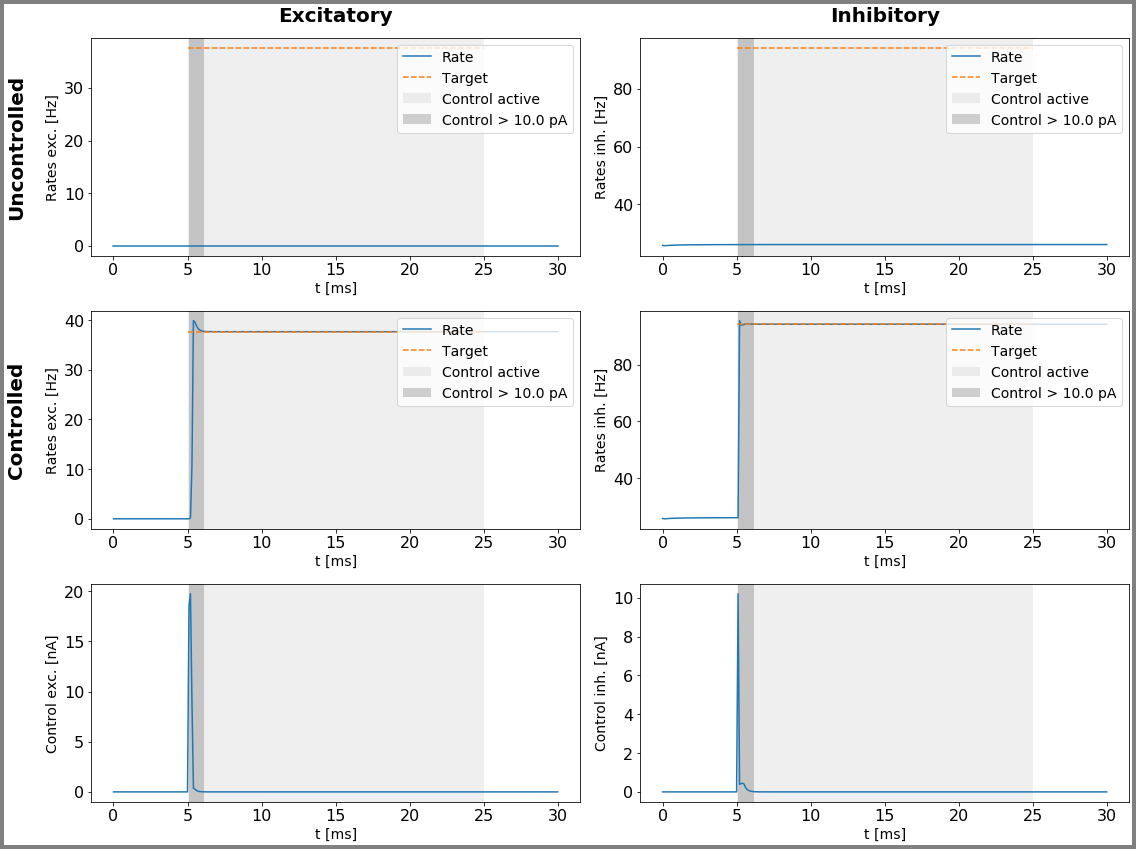

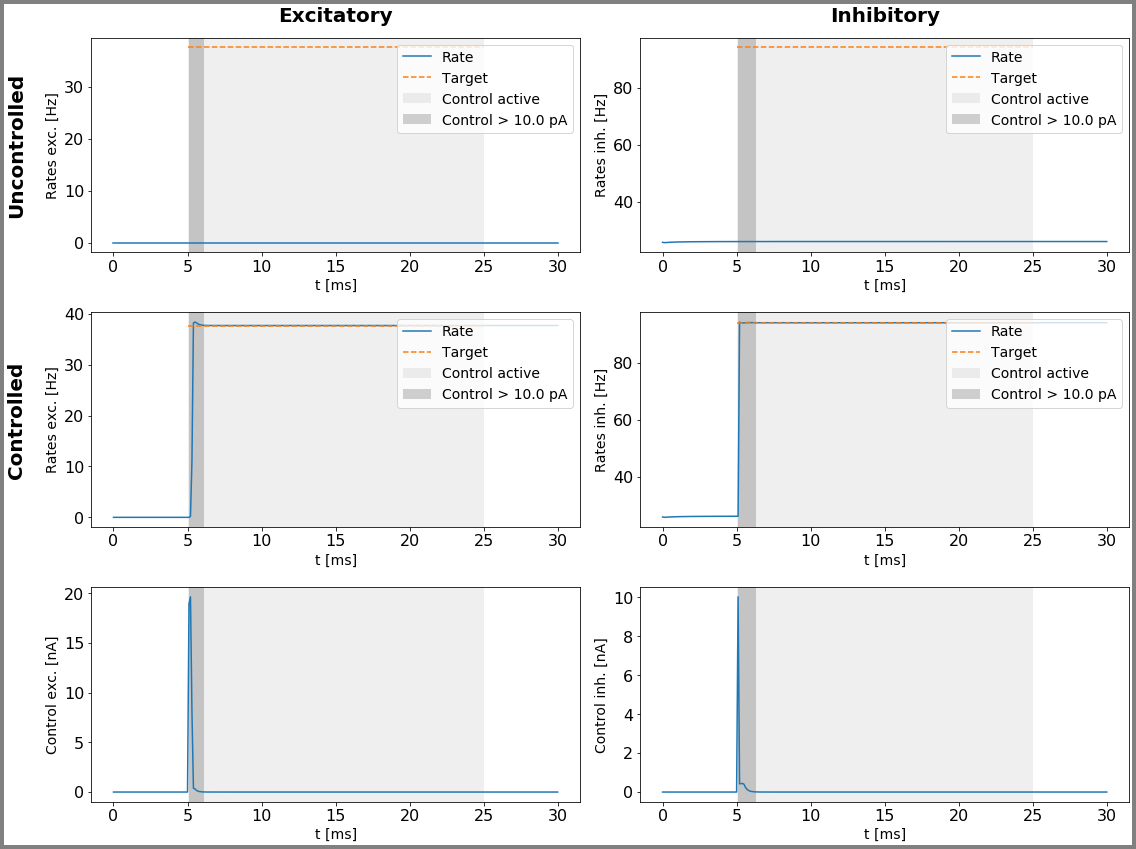

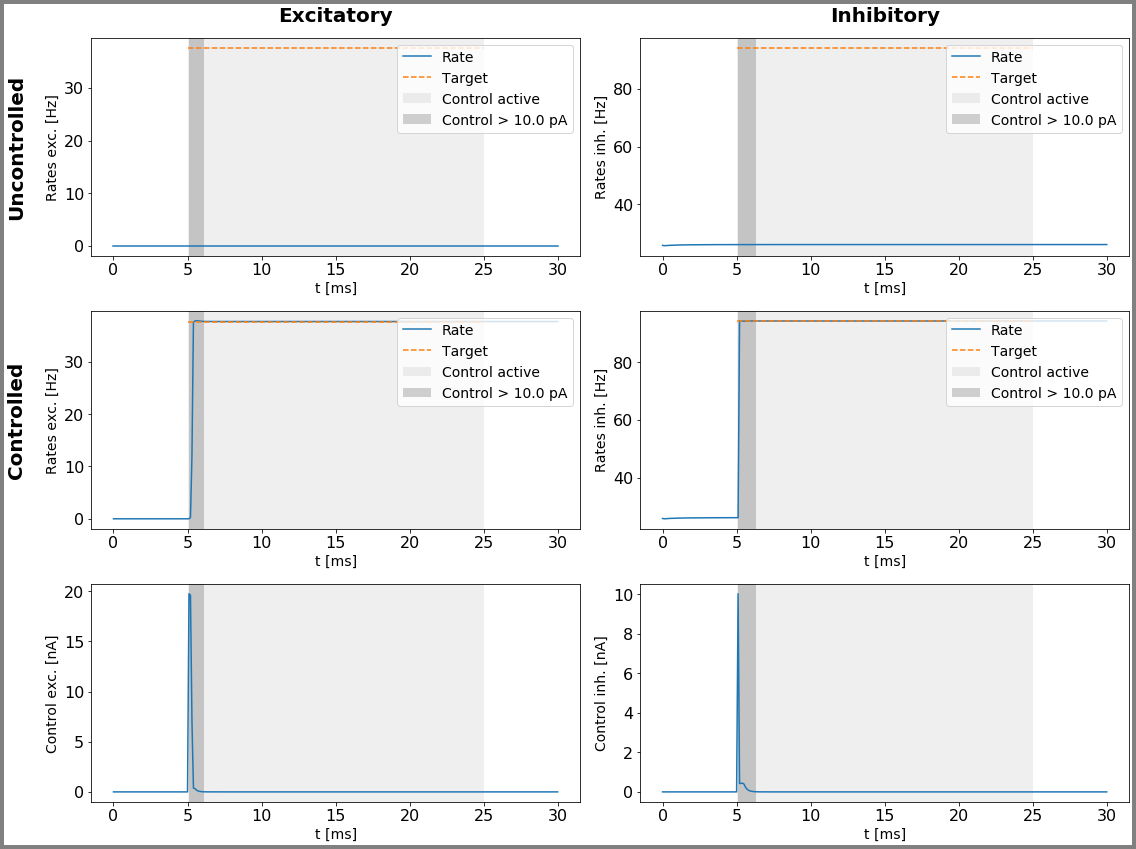

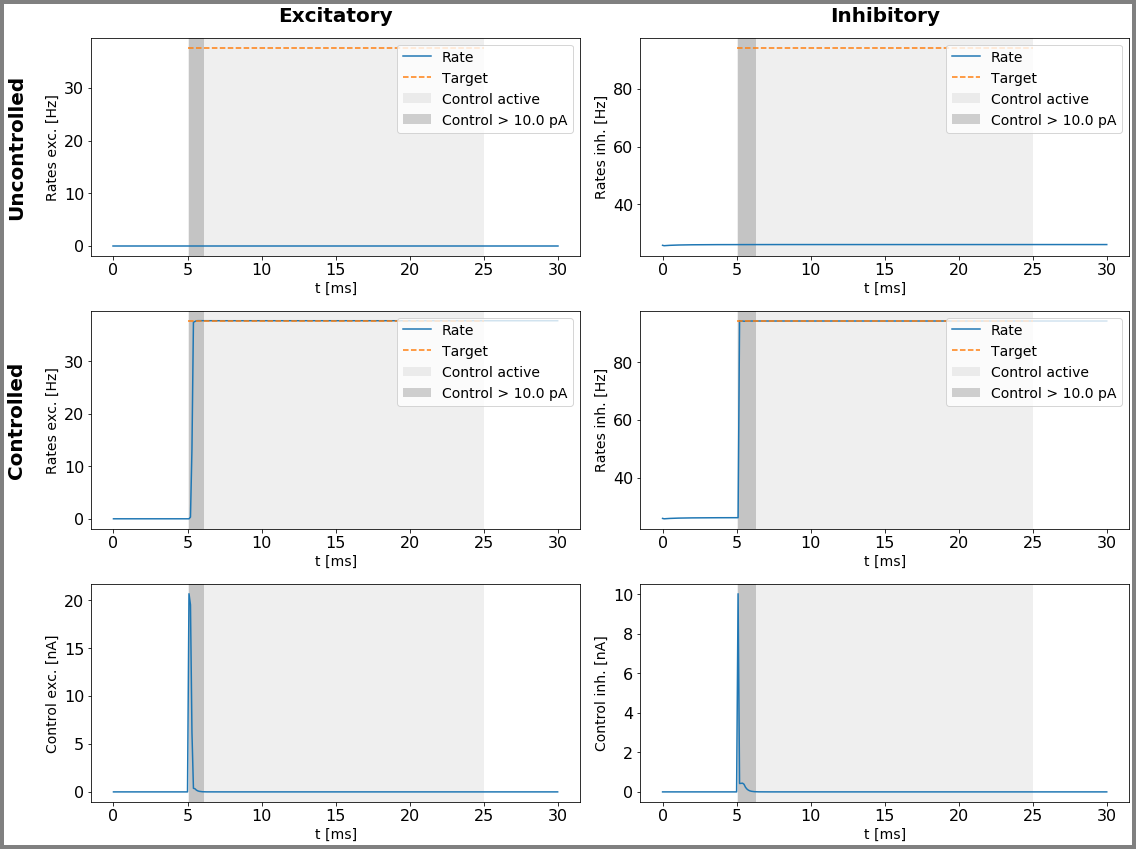

In [15]:
for i in range(loop_it):
    setinitvars(low_state_vars)
    cntrlA2_, bestStateA2_, costA2_, runtimeA2_ = aln.A2(cntrl1, target_lh, max_iteration_ = max_it, tolerance_ = tol,
                    include_timestep_ = incl_step, start_step_ = start_step, test_step_ = test_step,
                    max_control_ = max_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post)
    
    #if (i % 10 == 0):
    plotFunc.plot_control(aln, cntrlA2_, dur, dur_pre, dur_post, low_state_vars, target_lh,
                      path, filename_ = str('p1_e1_u1nA_LowHigh_' + alg + "_" + str(i*max_it) ))
    
    cntrl1 = cntrlA2_[:,:,50:251]
    if i == 0:
        costA2[0] = costA2_[0]
    costA2[max_it*i+1:max_it*i+max_it+1] = costA2_[1:]
    runtimeA2[max_it*i+1:max_it*i+max_it+1] = runtimeA2[max_it*i] + runtimeA2_[1:]

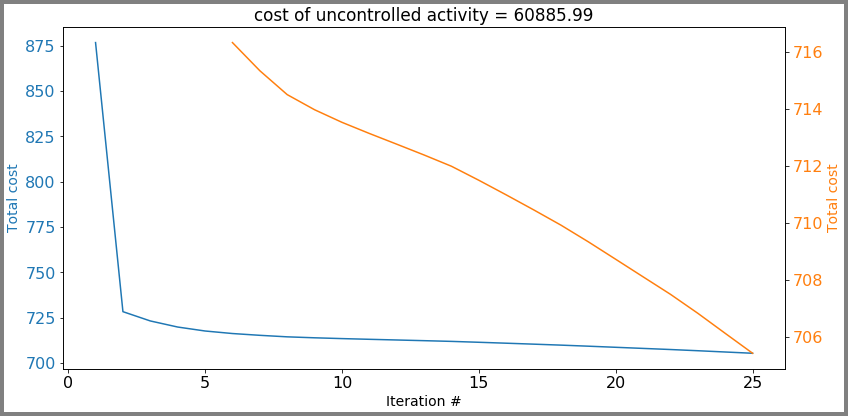

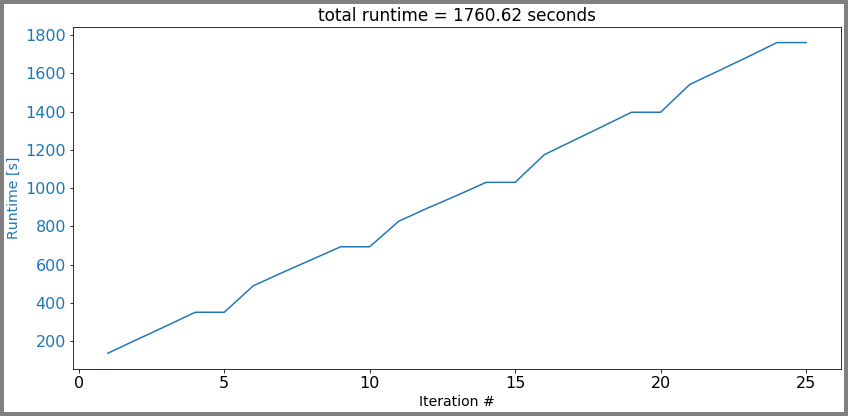

In [16]:
costA2 = np.array(costA2[:])
runtimeA2 = np.array(runtimeA2[:])
plotFunc.plot_convergence(costA2, path, str("p1_e1_u1nA_LowHigh_cost_" + alg) )
plotFunc.plot_runtime(runtimeA2, path, str("p1_e1_u1nA_LowHigh_runtime_" + alg))

cost A1 =  14731.515181036133
cost A2 =  705.4408897186873
runtime A1 =  387.55935089999997
runtime A2 =  1760.6249652000001


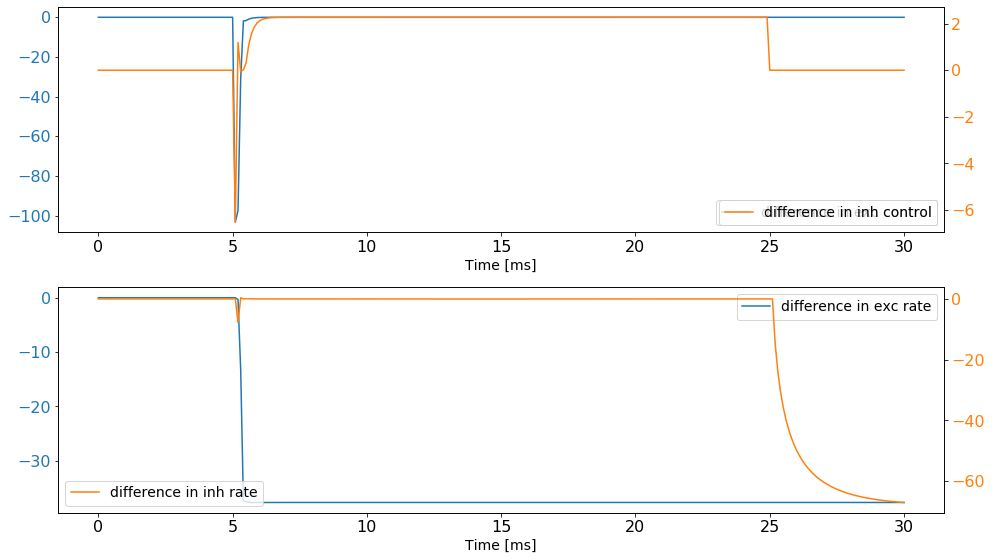

In [17]:
diff_cntrl = (cntrlA1_ - cntrlA2_)
diff_state = (bestStateA1_[:,:3,:] - bestStateA2_)
diff_cost = costA1[-1] - costA2[-1]
diff_runtime = runtimeA1[-1] - runtimeA2[-1]

print("cost A1 = ", costA1[-1])
print("cost A2 = ", costA2[-1])
print("runtime A1 = ", runtimeA1[-1])
print("runtime A2 = ", runtimeA2[-1])

fig, axes = plt.subplots(2, figsize=(14, 8))

color = 'tab:blue'
axes[0].set_xlabel('Time [ms]')
axes[0].plot(aln.t, diff_cntrl[0,0,:], label="difference in exc control", color=color)
axes[0].tick_params(axis='y', labelcolor=color)
axes[1].set_xlabel('Time [ms]')
axes[1].plot(aln.t, diff_state[0,0,:], label="difference in exc rate", color=color)
axes[1].tick_params(axis='y', labelcolor=color)

ax1 = axes[0].twinx() 
color = 'tab:orange'
ax1.plot(aln.t, diff_cntrl[0,1,:], label="difference in inh control", color=color)
ax1.tick_params(axis='y', labelcolor=color)

ax2 = axes[1].twinx() 
color = 'tab:orange'
ax2.plot(aln.t, diff_state[0,1,:], label="difference in inh rate", color=color)
ax2.tick_params(axis='y', labelcolor=color)

for i in range(2):
    axes[i].legend()
ax1.legend()
ax2.legend()
    
fig.tight_layout()  # otherwise the right y-label is slightly clipped

plt.savefig(os.path.join(path,"p1_e1_u1nA_LowHigh_compare"))

In [18]:
rate = aln.params.precalc_r
v = aln.params.precalc_V
tau = aln.params.precalc_tau_mu

ir = aln.params.Irange
sr = aln.params.sigmarange

def getindex(lower, upper, length, x_):
    return int( (x_ - lower) * (length-1) / (upper - lower) )

def get_value(lower, upper, length, index_):
    return lower + index_ * (upper - lower) / (length-1)

gradient_r = np.zeros(( len(ir), len(sr), 2 ))
gradient_v = np.zeros(( len(ir), len(sr), 2 ))
gradient_t = np.zeros(( len(ir), len(sr), 2 ))
for sigma in range(len(sr)-1):
    for mu in range(len(ir)-1):
        res0 = jac_aln.der_mu_up(aln, sr[sigma], ir[mu], rate)
        res1 = jac_aln.der_sigma(aln, sr[sigma], ir[mu], rate)
        gradient_r[mu, sigma, 0] = res0
        gradient_r[mu, sigma, 1] = res1
        res0 = jac_aln.der_mu_up(aln, sr[sigma], ir[mu], v)
        res1 = jac_aln.der_sigma(aln, sr[sigma], ir[mu], v)
        gradient_v[mu, sigma, 0] = res0
        gradient_v[mu, sigma, 1] = res1
        res0 = jac_aln.der_mu_up(aln, sr[sigma], ir[mu], tau)
        res1 = jac_aln.der_sigma(aln, sr[sigma], ir[mu], tau)
        gradient_t[mu, sigma, 0] = res0
        gradient_t[mu, sigma, 1] = res1
        
